# 国別医療支出・平均寿命：事前分析計画

run_id: `v020-exp-20`。実行経路はJupyter MCPのみ。端末、subprocess、外部スクリプト、作業エージェントは使用しない。API認証情報はNotebook・出力・ログへ記録しない。

## 対象と選定
Kaggle Python SDKで `health expenditure life expectancy`、必要なら `healthexp` / `health expenditure` を検索し、国・年・支出・寿命がそろう公開CSVを優先する。検索結果、slug、ファイル一覧、取得日時、SHA-256、列の意味・未検証事項を記録する。対応CSVをKaggle APIで検索・取得できない場合だけ指定旧実験の公開CSVへ切り替える。Kaggle掲載版との完全同一性は主張しない。

## 分析設計（データ・結果を見る前）
1. 国×年の一意性、欠損、数値型、年・寿命・支出の意味的範囲、収録の不均衡を調べる。独立参照がない場合は外部検証済みとしない。
2. 全観測の散布図と相関は記述のみ。同じ国の反復観測は独立でないため通常の相関p値を推論に使わない。
3. 共通年のバランスパネルを主分析とし、国平均（国間）、国固定効果（国内の変化）、国＋年固定効果（共通時代変化を調整）を分ける。主説明変数は支出のlog2、係数は支出倍増に対応する寿命の年差。ただし金額単位・価格調整が未確認なら「記録支出」倍増の関連と呼ぶ。
4. 図表は国ごとの経年線、同一年の国比較、国平均比較、国・年効果を除いた残差、仕様比較を選ぶ。軸・凡例・タイトルと文字欠落を確認し、`visual_audit=True`で監査する。
5. 国数が少ない場合、通常の有意差主張は避け、クラスタ標準誤差を参考値とし、除外国・期間・線形/対数・差分の感度を優先。交絡（所得、教育、行動、制度、人口構成等）、逆因果、支出価格・為替、ラグ、選択バイアスを説明し因果効果と呼ばない。
6. 初回結果を読み直し、実質的な未解決点に最大3回の自然言語追加依頼を記録・実行する。追加価値がなくなれば停止理由を記録する。
7. 全コードセルを上から再実行し、根拠参照を再接続してNotebook監査・lifecycleの終了状態を記録する。


In [1]:
# 実行環境・ライフサイクル
from pathlib import Path
from datetime import datetime, timezone
from dataclasses import asdict
from contextlib import contextmanager, redirect_stdout, redirect_stderr
import os, sys, io, json, hashlib, logging, warnings, zipfile, re
import numpy as np
import pandas as pd
import nbformat
from IPython.display import display, Markdown, Image
repo = Path('/home/nahisaho/GitHub/jupytermind')
if str(repo / 'src') not in sys.path:
    sys.path.insert(0, str(repo / 'src'))
os.environ['AI_DATA_SCIENTIST_PROJECTS_ROOT'] = str(repo / 'benchmark/projects')
from ai_data_scientist import project_manager as pm, lifecycle, language_router
from ai_data_scientist import ingestion, cleaning, eda, stats_analysis
from ai_data_scientist import data_definition, analysis_assumptions, data_quality, sensitivity
from ai_data_scientist import visualization, insight_engine, notebook_audit
handle = pm.resolve_project('kaggle-v020-kaggle-exp-20-healthexp')
pm.ensure_notebook(handle)
data_dir = pm.ensure_data_dir(handle)
RUN_ID = 'v020-exp-20'
lifecycle.register_run(RUN_ID, handle.notebook_path)
phase_log = []
def log_phase(phase, event):
    phase_log.append({'phase': phase, 'event': event, 'at_utc': datetime.now(timezone.utc).isoformat()})
@contextmanager
def phase(name):
    if lifecycle.is_cancel_requested(RUN_ID):
        lifecycle.mark_failed(RUN_ID)
        raise RuntimeError('キャンセル要求を検出したため実行を停止しました')
    lifecycle.mark_execution_start(RUN_ID)
    log_phase(name, 'execution_start')
    try:
        yield
    except Exception:
        lifecycle.mark_failed(RUN_ID)
        log_phase(name, 'failed')
        raise
    finally:
        lifecycle.mark_execution_end(RUN_ID)
        log_phase(name, 'execution_end')
def queued_write(mutation):
    lifecycle.mark_write_start(RUN_ID)
    log_phase('notebook', 'write_start')
    try:
        return pm.enqueue_write(handle, mutation)
    except Exception:
        lifecycle.mark_failed(RUN_ID)
        raise
    finally:
        lifecycle.mark_write_end(RUN_ID)
        log_phase('notebook', 'write_end')
{'run_id': RUN_ID, 'language': language_router.detect_language('国別医療支出と平均寿命を日本語で分析してください'), 'notebook': str(handle.notebook_path), 'lifecycle': asdict(lifecycle.get_run_status(RUN_ID))}


{'run_id': 'v020-exp-20',
 'language': 'ja',
 'notebook': '/home/nahisaho/GitHub/jupytermind/benchmark/projects/kaggle-v020-kaggle-exp-20-healthexp/notebooks/kaggle-v020-kaggle-exp-20-healthexp.ipynb',
 'lifecycle': {'run_id': 'v020-exp-20',
  'state': 'running',
  'active_cell_executions': 0,
  'pending_notebook_writes': 0,
  'locks_held': 0,
  'notebook_path': '/home/nahisaho/GitHub/jupytermind/benchmark/projects/kaggle-v020-kaggle-exp-20-healthexp/notebooks/kaggle-v020-kaggle-exp-20-healthexp.ipynb',
  'reason': None}}

In [2]:
# Kaggle認証・公開データ検索（機密情報を出力しない）
kaggle_events = []
candidates = []
file_candidates = []
api = None
with phase('kaggle_search'):
    sink = io.StringIO()
    old_disable = logging.root.manager.disable
    try:
        logging.disable(logging.CRITICAL)
        with redirect_stdout(sink), redirect_stderr(sink):
            from kaggle.api.kaggle_api_extended import KaggleApi
            api = KaggleApi()
            api.authenticate()
        kaggle_events.append({'operation': 'KaggleApi().authenticate()', 'status': 'ok'})
    except Exception as exc:
        kaggle_events.append({'operation': 'KaggleApi().authenticate()', 'status': 'failed', 'error_type': type(exc).__name__, 'http_status': getattr(exc, 'status', None), 'message': '認証失敗。例外本文と認証情報は安全のため記録しない。'})
    finally:
        logging.disable(old_disable)
        sink.close()
    if api is not None and kaggle_events[-1]['status'] == 'ok':
        for query in ['health expenditure life expectancy', 'healthexp', 'health expenditure']:
            sink = io.StringIO()
            old_disable = logging.root.manager.disable
            try:
                logging.disable(logging.CRITICAL)
                with redirect_stdout(sink), redirect_stderr(sink):
                    hits = api.dataset_list(search=query, page=1)
                entries = [{'slug': str(d.ref), 'title': str(d.title), 'bytes': int(getattr(d, 'total_bytes', 0) or 0)} for d in hits]
                kaggle_events.append({'operation': 'dataset_list', 'query': query, 'status': 'ok', 'results': entries})
                candidates.extend(entries)
            except Exception as exc:
                kaggle_events.append({'operation': 'dataset_list', 'query': query, 'status': 'failed', 'error_type': type(exc).__name__, 'http_status': getattr(exc, 'status', None), 'message': '検索API失敗。例外本文は機密漏えい防止のため非保存。'})
            finally:
                logging.disable(old_disable)
                sink.close()
        seen = set()
        ranked = sorted(candidates, key=lambda d: (('healthexp' not in (d['slug']+' '+d['title']).lower()), ('life' not in d['title'].lower()), d['bytes']))
        for entry in ranked:
            slug = entry['slug']
            if slug in seen or len(seen) >= 8:
                continue
            seen.add(slug)
            sink = io.StringIO()
            old_disable = logging.root.manager.disable
            try:
                logging.disable(logging.CRITICAL)
                with redirect_stdout(sink), redirect_stderr(sink):
                    response = api.dataset_list_files(slug)
                files = [{'name': str(f.name), 'bytes': int(getattr(f, 'total_bytes', getattr(f, 'size', 0)) or 0)} for f in response.files]
                kaggle_events.append({'operation': 'dataset_list_files', 'slug': slug, 'status': 'ok', 'files': files})
                file_candidates.extend({'slug': slug, 'title': entry['title'], **f} for f in files if f['name'].lower().endswith('.csv') and f['bytes'] <= 30_000_000)
            except Exception as exc:
                kaggle_events.append({'operation': 'dataset_list_files', 'slug': slug, 'status': 'failed', 'error_type': type(exc).__name__, 'http_status': getattr(exc, 'status', None), 'message': 'ファイル一覧API失敗。例外本文は非保存。'})
            finally:
                logging.disable(old_disable)
                sink.close()
{'kaggle_events': kaggle_events, 'csv_candidates': file_candidates, 'fallback_permitted': not bool(file_candidates)}


{'kaggle_events': [{'operation': 'KaggleApi().authenticate()', 'status': 'ok'},
  {'operation': 'dataset_list',
   'query': 'health expenditure life expectancy',
   'status': 'ok',
   'results': [{'slug': 'kumarajarshi/life-expectancy-who',
     'title': 'Life Expectancy (WHO)',
     'bytes': 121472},
    {'slug': 'utkarshxy/who-worldhealth-statistics-2020-complete',
     'title': 'World Health Statistics 2020|Complete|Geo-Analysis',
     'bytes': 1440599},
    {'slug': 'mjshri23/life-expectancy-and-socio-economic-world-bank',
     'title': 'Life expectancy & Socio-Economic (world bank)',
     'bytes': 172517},
    {'slug': 'saurabhbadole/life-expectancy-based-on-geographic-locations',
     'title': 'Life Expectancy based on Geographic Locations',
     'bytes': 121081},
    {'slug': 'uom190346a/health-and-demographics-dataset',
     'title': 'Health and Demographics Dataset',
     'bytes': 76413},
    {'slug': 'nelgiriyewithana/countries-of-the-world-2023',
     'title': 'Global Countr

# データ選定の詳細

検索結果に明示的に両変数と長期収録を含む `belbino/life-expectancy-healthcare-spending-1960-present` を調べる。CSVの実列と欠損を確認後に採否を決める。異なる単位の支出を混合しない。

対象CSVのAPI取得に成功したため、指定の旧実験CSVフォールバックは使用しない。初回は関連CSVも取得して列を点検したが、再実行は実分析に使うhealth_panel.csv / country_metadata.csvとREADME.mdのみを再取得する。全取得ファイルの初回SHA-256はNotebook metadataのinitial_acquisition_provenance、実使用3ファイルはinitial snapshotに記録。

In [3]:
# 取得対象の明示的選定とKaggleファイル取得
import inspect
selected_slug = 'belbino/life-expectancy-healthcare-spending-1960-present'
selected_files = []
provenance = []
source_metadata = {}
with phase('kaggle_acquisition'):
    sink = io.StringIO()
    old_disable = logging.root.manager.disable
    try:
        logging.disable(logging.CRITICAL)
        with redirect_stdout(sink), redirect_stderr(sink):
            listing = api.dataset_list_files(selected_slug)
        selected_files = [{'name': str(f.name), 'bytes': int(getattr(f, 'total_bytes', getattr(f, 'size', 0)) or 0)} for f in listing.files]
        kaggle_events.append({'operation': 'dataset_list_files', 'slug': selected_slug, 'status': 'ok', 'files': selected_files, 'selection_reason': '検索結果に医療支出と寿命の両方・1960年以降を明示。WHO版のpercentage expenditureの曖昧さより優先。'})
    except Exception as exc:
        kaggle_events.append({'operation': 'dataset_list_files', 'slug': selected_slug, 'status': 'failed', 'error_type': type(exc).__name__, 'http_status': getattr(exc, 'status', None)})
    finally:
        logging.disable(old_disable)
        sink.close()
    stage = data_dir / selected_slug.replace('/', '--')
    stage.mkdir(parents=True, exist_ok=True)
    download_candidates = [f for f in selected_files if f['name'] in ['health_panel.csv','country_metadata.csv'] and f['bytes'] <= 30_000_000]
    for entry in download_candidates:
        sink = io.StringIO()
        old_disable = logging.root.manager.disable
        try:
            logging.disable(logging.CRITICAL)
            with redirect_stdout(sink), redirect_stderr(sink):
                api.dataset_download_file(selected_slug, entry['name'], path=str(stage), force=True, quiet=True)
            basename = Path(entry['name']).name
            local = stage / basename
            archive = stage / (basename + '.zip')
            if not local.exists() and archive.exists():
                with zipfile.ZipFile(archive) as zf:
                    matches = [n for n in zf.namelist() if Path(n).name == basename]
                    if len(matches) != 1:
                        raise ValueError('ZIP内の対象ファイルが一意でない')
                    local.write_bytes(zf.read(matches[0]))
            if not local.exists():
                raise FileNotFoundError('Kaggleダウンロード先でファイルが見つからない')
            header = pd.read_csv(local, nrows=4)
            record = {'provider': 'Kaggle', 'slug': selected_slug, 'url': 'https://www.kaggle.com/datasets/' + selected_slug, 'filename': entry['name'], 'local_path': str(local), 'retrieved_at_utc': datetime.now(timezone.utc).isoformat(), 'sha256': hashlib.sha256(local.read_bytes()).hexdigest(), 'bytes': local.stat().st_size, 'columns': list(header.columns)}
            provenance.append(record)
            kaggle_events.append({'operation': 'dataset_download_file', 'slug': selected_slug, 'filename': entry['name'], 'status': 'ok'})
        except Exception as exc:
            kaggle_events.append({'operation': 'dataset_download_file', 'slug': selected_slug, 'filename': entry['name'], 'status': 'failed', 'error_type': type(exc).__name__, 'http_status': getattr(exc, 'status', None), 'message': '取得失敗。機密を含み得る例外本文は非保存。'})
        finally:
            logging.disable(old_disable)
            sink.close()
    assert {p['filename'] for p in provenance} >= {'health_panel.csv','country_metadata.csv'}, 'Kaggle APIで必要CSVの取得に失敗。既存ファイルを新規取得として扱わない。'
    sink = io.StringIO()
    old_disable = logging.root.manager.disable
    try:
        logging.disable(logging.CRITICAL)
        with redirect_stdout(sink), redirect_stderr(sink):
            api.dataset_metadata(selected_slug, path=str(stage))
        metadata_path = stage / 'dataset-metadata.json'
        if metadata_path.exists():
            raw_metadata = json.loads(metadata_path.read_text())
            source_metadata = {k: raw_metadata.get(k) for k in ['id', 'title', 'subtitle', 'description', 'licenses', 'resources'] if k in raw_metadata}
        kaggle_events.append({'operation': 'dataset_metadata', 'status': 'ok', 'slug': selected_slug})
    except Exception as exc:
        kaggle_events.append({'operation': 'dataset_metadata', 'status': 'failed', 'slug': selected_slug, 'error_type': type(exc).__name__, 'http_status': getattr(exc, 'status', None)})
    finally:
        logging.disable(old_disable)
        sink.close()
{'selection': selected_slug, 'file_listing': selected_files, 'provenance': provenance, 'source_metadata': source_metadata, 'recent_api_events': kaggle_events[-(len(download_candidates)+2):], 'fallback_used': False}


{'selection': 'belbino/life-expectancy-healthcare-spending-1960-present',
 'file_listing': [{'name': 'README.md', 'bytes': 4266},
  {'name': 'context.csv', 'bytes': 1192110},
  {'name': 'country_metadata.csv', 'bytes': 23313},
  {'name': 'health_panel.csv', 'bytes': 2722020},
  {'name': 'health_spending.csv', 'bytes': 437554},
  {'name': 'hospital_capacity.csv', 'bytes': 393337},
  {'name': 'infant_mortality.csv', 'bytes': 826967},
  {'name': 'life_expectancy.csv', 'bytes': 1086045},
  {'name': 'ml_features.csv', 'bytes': 14596006}],
 'provenance': [{'provider': 'Kaggle',
   'slug': 'belbino/life-expectancy-healthcare-spending-1960-present',
   'url': 'https://www.kaggle.com/datasets/belbino/life-expectancy-healthcare-spending-1960-present',
   'filename': 'country_metadata.csv',
   'local_path': '/home/nahisaho/GitHub/jupytermind/benchmark/projects/kaggle-v020-kaggle-exp-20-healthexp/data/belbino--life-expectancy-healthcare-spending-1960-present/country_metadata.csv',
   'retrieved_at

In [4]:
# データ辞書・原データの読み込みと基本点検
with phase('definition_ingestion'):
    sink = io.StringIO()
    old_disable = logging.root.manager.disable
    try:
        logging.disable(logging.CRITICAL)
        with redirect_stdout(sink), redirect_stderr(sink):
            api.dataset_download_file(selected_slug, 'README.md', path=str(stage), force=True, quiet=True)
        readme_path = stage / 'README.md'
        if not readme_path.exists() and (stage / 'README.md.zip').exists():
            with zipfile.ZipFile(stage / 'README.md.zip') as zf:
                readme_path.write_bytes(zf.read('README.md'))
        readme_text = readme_path.read_text(encoding='utf-8')
        provenance.append({'provider': 'Kaggle', 'slug': selected_slug, 'filename': 'README.md', 'retrieved_at_utc': datetime.now(timezone.utc).isoformat(), 'sha256': hashlib.sha256(readme_path.read_bytes()).hexdigest()})
        kaggle_events.append({'operation': 'dataset_download_file', 'filename': 'README.md', 'status': 'ok'})
    except Exception as exc:
        readme_text = ''
        kaggle_events.append({'operation': 'dataset_download_file', 'filename': 'README.md', 'status': 'failed', 'error_type': type(exc).__name__, 'message': '辞書未取得。定義は推定/未確認扱い。'})
    finally:
        logging.disable(old_disable)
        sink.close()
    loaded = ingestion.ingest(ingestion.SourceSpec('csv', str(stage / 'health_panel.csv')), row_limit=100000)
    assert not loaded.truncated, '全行分析の前提：切詰め不可'
    raw = loaded.dataframe
    metadata = ingestion.ingest(ingestion.SourceSpec('csv', str(stage / 'country_metadata.csv'))).dataframe
    assert {'country_code','country_name','year','life_expectancy_total','health_spend_per_capita_usd','health_spend_pct_gdp','gdp_per_capita_usd','population_total'}.issubset(raw.columns)
    basic_eda = eda.explore(raw)
    year_coverage = raw.groupby('year').agg(rows=('country_code','size'), life=('life_expectancy_total','count'), spend=('health_spend_per_capita_usd','count'))
    complete_mask = raw[['life_expectancy_total','health_spend_per_capita_usd']].notna().all(axis=1)
    overview = {'raw_rows': len(raw), 'countries_or_aggregates': raw.country_code.nunique(), 'year_min': int(raw.year.min()), 'year_max': int(raw.year.max()), 'duplicate_country_year': int(raw.duplicated(['country_code','year']).sum()), 'missing_by_column': raw[['life_expectancy_total','health_spend_per_capita_usd','health_spend_pct_gdp','gdp_per_capita_usd','population_total']].isna().sum().to_dict(), 'complete_spend_life_rows': int(complete_mask.sum()), 'region_counts': metadata.region.fillna('<missing>').value_counts().to_dict()}
display(Markdown('## Kaggle収録README（取得した原文）\n\n' + readme_text))
display(year_coverage.tail(30))
{'overview': overview, 'eda_dtypes': basic_eda.dtypes, 'eda_non_null_counts': basic_eda.non_null_counts, 'eda_missing_summary': basic_eda.missing_summary, 'eda_describe': basic_eda.describe, 'data_preview': raw.head(3).to_dict(orient='records'), 'metadata_preview': metadata.head(8).to_dict(orient='records'), 'provenance': provenance}


## Kaggle収録README（取得した原文）

# 🏥 Global Life Expectancy vs Healthcare Spending (1960-Present)

**Source**: World Bank Open Data API - https://data.worldbank.org
**API Key Required**: No - the World Bank API is free and open.
**Last Updated**: 2026-04-24

## World Bank Indicator Codes

| Indicator Code | Description | File |
|----------------|-------------|------|
| SP.DYN.LE00.IN | Life expectancy at birth, total (years) | life_expectancy.csv |
| SP.DYN.LE00.FE.IN | Life expectancy at birth, female (years) | life_expectancy.csv |
| SP.DYN.LE00.MA.IN | Life expectancy at birth, male (years) | life_expectancy.csv |
| SH.XPD.CHEX.GD.ZS | Current health expenditure (% of GDP) | health_spending.csv |
| SH.XPD.CHEX.PC.CD | Current health expenditure per capita (USD) | health_spending.csv |
| SH.MED.BEDS.ZS | Hospital beds per 1,000 people | hospital_capacity.csv |
| SH.MED.PHYS.ZS | Physicians per 1,000 people | hospital_capacity.csv |
| SH.MED.NUMW.P3 | Nurses and midwifery personnel per 1,000 | hospital_capacity.csv |
| SP.DYN.IMRT.IN | Infant mortality rate (per 1,000 live births) | infant_mortality.csv |
| SH.DYN.MORT | Under-5 mortality rate (per 1,000 live births) | infant_mortality.csv |
| SH.STA.MMRT | Maternal mortality ratio (per 100,000 live births) | infant_mortality.csv |
| NY.GDP.PCAP.CD | GDP per capita, current USD | context.csv |
| SP.POP.TOTL | Population, total | context.csv |

## Output Files

| File | Description |
|------|-------------|
| life_expectancy.csv | LE at birth (total/female/male), gender gap, YoY change — all countries |
| health_spending.csv | Health spend % GDP + per capita USD, spend tier, YoY change |
| hospital_capacity.csv | Beds/physicians/nurses per 1,000, total health workers, capacity tier |
| infant_mortality.csv | Infant, under-5, maternal mortality + YoY improvement + burden tier |
| context.csv | GDP per capita, population, log GDP, income tier |
| country_metadata.csv | ISO codes, World Bank region, income group, lat/lon |
| health_panel.csv | All indicators merged on country_code + year (primary analysis file) |
| ml_features.csv | Lag 1-5, rolling 3/5-year, dummies, regression + classification targets |

## Derived Columns (health_panel.csv)

| Column | Formula | Interpretation |
|--------|---------|----------------|
| life_expectancy_gender_gap | female_LE - male_LE | Positive = women live longer |
| le_per_gdp_point | life_expectancy_total / health_spend_pct_gdp | Life-years per % of GDP spent on health |
| le_per_1k_spend | life_expectancy_total / (health_spend_per_capita_usd / 1000) | Life-years per $1,000 per capita health spend |
| le_spend_residual | Actual LE - OLS predicted LE from log(spend) | Positive = outperforms spending level |
| efficiency_score | le_per_1k_spend normalised 0-100 within each year | 100 = most efficient country that year |

## ML Targets (ml_features.csv)

| Column | Type | Description |
|--------|------|-------------|
| target_le_next_year | float | Life expectancy next year (regression) |
| target_le_change_next_year | float | Change in life expectancy next year |
| target_le_improves | int | 1 if LE improves next year, else 0 (classification) |
| target_le_5yr | float | Life expectancy 5 years ahead (long-horizon regression) |
| target_le_gain_5yr | float | LE gain over next 5 years |
| target_im_next_year | float | Infant mortality next year (regression) |
| target_im_improvement | float | Infant mortality reduction next year (positive = improving) |

## Key Historical Health Events

| Period | Event | Impact on Data |
|--------|-------|----------------|
| 1960s–1980s | Green Revolution + basic healthcare expansion | Rapid LE gains in low-income countries |
| 1981–2000 | HIV/AIDS epidemic in Sub-Saharan Africa | LE reversed by 5-15 years in hardest-hit nations |
| 1990s | Post-Soviet health system collapse | Sharp LE drops in Eastern Europe/Central Asia |
| 2000s | PEPFAR, Global Fund, MDGs | LE rebounds; infant mortality falls sharply in Africa |
| 2020–2022 | COVID-19 pandemic | Global LE dropped ~1.8 years (largest decline since WWII) |

## Source & License
World Bank Open Data — https://data.worldbank.org
API endpoint: https://api.worldbank.org/v2/
License: CC BY 4.0 — https://datacatalog.worldbank.org/public-licenses

,rows,life,spend
year,,,
1995,265,265,0
1996,265,265,0
1997,265,265,0
1998,265,265,0
1999,265,265,0
2000,265,265,232
2001,265,265,232
2002,265,265,233
2003,265,265,235


{'overview': {'raw_rows': 17210,
  'countries_or_aggregates': 264,
  'year_min': 1960,
  'year_max': 2024,
  'duplicate_country_year': 0,
  'missing_by_column': {'life_expectancy_total': 19,
   'health_spend_per_capita_usd': 11497,
   'health_spend_pct_gdp': 11494,
   'gdp_per_capita_usd': 2649,
   'population_total': 15},
  'complete_spend_life_rows': 5713,
  'region_counts': {'Aggregates': 79,
   'Europe & Central Asia': 58,
   'Sub-Saharan Africa ': 48,
   'Latin America & Caribbean ': 42,
   'East Asia & Pacific': 37,
   'Middle East, North Africa, Afghanistan & Pakistan': 23,
   'South Asia': 6,
   'North America': 3}},
 'eda_dtypes': {'country_code': 'str',
  'country_name': 'str',
  'year': 'int64',
  'life_expectancy_total': 'float64',
  'life_expectancy_female': 'float64',
  'life_expectancy_male': 'float64',
  'life_expectancy_gender_gap': 'float64',
  'le_total_yoy_change': 'float64',
  'region': 'float64',
  'income_group': 'float64',
  'iso2_code': 'float64',
  'health_spe

# 意味的検査と分析前提

主分析の対象は国・地域の完全観測パネルで、人口重み付きの世界人口平均とは異なる。1960年以降の寿命データはあるが医療支出は2000年以降のため、支出との関係を1960年まで外挿しない。現時点のincome_groupを歴史的所得階級として解釈しない。欠損を補間せず、集計地域を国と数えない。

In [5]:
# 意味的品質検査、国コード修復、定義manifestと分析対象
with phase('semantic_quality'):
    raw_preserved = pd.read_csv(stage / 'health_panel.csv', keep_default_na=False, na_values=[''])
    meta_preserved = pd.read_csv(stage / 'country_metadata.csv', keep_default_na=False, na_values=[''])
    pre_anomalies = data_quality.detect_anomalies(raw, schema={'country_code': {'not_null': True}, 'year': {'min': 1960, 'max': 2026, 'not_null': True}, 'life_expectancy_total': {'min': 0, 'max': 120}, 'health_spend_per_capita_usd': {'min': 0, 'max': 100000}})
    assert meta_preserved.iso2_code.is_unique, 'メタデータISO2重複：自動結合不可'
    assert raw_preserved.country_code.notna().all(), 'ISO2が欠損している'
    unmatched_keys = sorted(set(raw_preserved.country_code)-set(meta_preserved.iso2_code))
    assert not unmatched_keys, f'ISO2不一致：{unmatched_keys}'
    original_region_missing = int(raw_preserved.region.isna().sum())
    coded = raw_preserved.drop(columns=['region','income_group','iso2_code']).rename(columns={'country_code':'source_country_code','country_name':'source_country_name'}).merge(meta_preserved[['country_name','country_code','iso2_code','region','income_group']], left_on='source_country_code',right_on='iso2_code',how='left',validate='many_to_one')
    name_mismatches = coded.loc[coded.source_country_name.notna() & coded.source_country_name.str.strip().ne(coded.country_name.str.strip()), ['source_country_code','source_country_name','country_name']].drop_duplicates().to_dict(orient='records')
    assert not name_mismatches, f'コード結合後の国名不一致：{name_mismatches}'
    coded['region'] = coded.region.str.strip()
    coded['income_group'] = coded.income_group.str.strip()
    assert coded.country_code.notna().all()
    assert coded.country_code.str.fullmatch(r'[A-Z0-9]{3}').all()
    assert (coded.source_country_code == coded.iso2_code).all(), '国名結合後にISO2が一致しない'
    assert not coded.duplicated(['country_code','year']).any()
    aggregate_rows = coded.region.eq('Aggregates')
    country_rows = coded.loc[~aggregate_rows].copy()
    post_anomalies = data_quality.detect_anomalies(country_rows, schema={'country_code': {'not_null': True, 'allowed': meta_preserved.loc[meta_preserved.region.str.strip().ne('Aggregates'), 'country_code']}, 'country_name': {'not_null': True}, 'year': {'not_null': True, 'min': 1960, 'max': 2026}, 'life_expectancy_total': {'min': 0, 'max': 120}, 'health_spend_per_capita_usd': {'min': 0, 'max': 100000}, 'health_spend_pct_gdp': {'min': 0, 'max': 100}, 'gdp_per_capita_usd': {'min': 0, 'max': 1000000}})
    required = ['country_code','country_name','year','life_expectancy_total','health_spend_per_capita_usd']
    analysis_columns = required + ['health_spend_pct_gdp','gdp_per_capita_usd','population_total','region','income_group']
    window = country_rows.loc[country_rows.year.between(2000,2023), analysis_columns].copy()
    clean_complete = cleaning.clean_dataset(window[required], operation='drop_na')
    eligible = window.loc[window[required].notna().all(axis=1) & window.health_spend_per_capita_usd.gt(0)].copy()
    eligible = eligible.rename(columns={'life_expectancy_total': 'life', 'health_spend_per_capita_usd': 'spend', 'health_spend_pct_gdp': 'spend_gdp', 'gdp_per_capita_usd': 'gdp', 'population_total': 'population'})
    eligible['log_spend'] = np.log2(eligible.spend)
    eligible['log_gdp'] = np.log2(eligible.gdp.where(eligible.gdp.gt(0)))
    full_codes = eligible.groupby('country_code').year.nunique().loc[lambda s: s.eq(24)].index
    panel = eligible.loc[eligible.country_code.isin(full_codes)].sort_values(['country_code','year']).reset_index(drop=True)
    assert panel.groupby('country_code').size().eq(24).all()
    assert len(panel) == panel.country_code.nunique()*24
    assert np.isfinite(panel[['life','spend','log_spend']]).all().all()
    F = data_definition.FieldValue
    readme_source = 'Kaggle README.md, SHA-256=' + hashlib.sha256((stage/'README.md').read_bytes()).hexdigest()
    definition_manifest = data_definition.build_manifest(
        source={'provider': F('Kaggle', 'verified', 'API取得'), 'slug': F(selected_slug, 'verified', '検索・取得API'), 'upstream': F('World Bank Open Data', 'verified', readme_source), 'license': F('CC BY 4.0 (README記載)', 'verified', readme_source), 'upstream_pipeline_correctness': F(None, 'unknown', 'Kaggle側の加工コード未検証')},
        dataset_scope={'unit': F('国/地域×暦年。集計地域を除外', 'verified', 'country_metadata.csv照合'), 'period': F('2000–2023、全24年の完全観測国', 'verified', 'coverage検査')},
        variables={
            'life': {'definition': F('出生時平均余命・男女計', 'verified', readme_source+' SP.DYN.LE00.IN'), 'unit': F('年', 'verified', readme_source), 'measurement_pathway': F('期間生命表指標であり実際の出生コホートの生涯追跡ではない', 'inferred', '指標コードから推定、公式方法論は未取得')},
            'spend': {'definition': F('1人当たり経常医療支出', 'verified', readme_source+' SH.XPD.CHEX.PC.CD'), 'unit': F('USD（名目・current）', 'inferred', 'World BankコードPC.CDと列名から推定'), 'price_adjustment': F('PPP・インフレ調整なしと推定', 'inferred', '指標コード'), 'capital_inclusion': F(None, 'unknown', '公式指標定義未取得')},
            'spend_gdp': {'unit': F('GDP比%', 'verified', readme_source+' SH.XPD.CHEX.GD.ZS')},
            'gdp': {'unit': F('1人当たりcurrent USD', 'verified', readme_source+' NY.GDP.PCAP.CD')},
            'country_code': {'definition': F('元データはWorld Bank ISO2形式、メタデータはISO3形式。ISO2の一意照合と国名整合検証後にISO3を採用', 'verified', '本セルのISO2キー照合assert')},
            'income_group': {'time_reference': F('現在の分類を全年度に付与していると推定', 'inferred', '国メタデータは年なし')}
        }, transformations=('NAをNamibiaのISO2として保持', 'ISO2一意結合・国名整合チェック', 'Aggregates除外', '2000–2023 complete balanced panel', 'log2(spend)'))
    unresolved = [(p, asdict(v)) for p,v in definition_manifest.unresolved_fields()]
    inferred = [(f'{var}.{key}', asdict(val)) for var, fields in definition_manifest.variables.items() for key,val in fields.items() if val.status == 'inferred']
    selection_report = {'raw_rows': len(raw), 'aggregate_rows_removed': int(aggregate_rows.sum()), 'aggregate_entities_removed': coded.loc[aggregate_rows,'country_code'].nunique(), 'country_territory_entities': country_rows.country_code.nunique(), 'window_rows': len(window), 'drop_na_impact': asdict(clean_complete), 'eligible_rows': len(eligible), 'eligible_countries': eligible.country_code.nunique(), 'balanced_rows': len(panel), 'balanced_countries': panel.country_code.nunique(), 'excluded_unbalanced_countries': sorted(set(eligible.country_name)-set(panel.country_name)), 'original_region_missing_rows': original_region_missing, 'NA_code_restored_rows': int(raw.country_code.isna().sum()), '2024_spend_observations': int(country_rows.loc[country_rows.year.eq(2024),'health_spend_per_capita_usd'].notna().sum())}
    # dataframe自体をmanifest出力へ混入させない
    selection_report['drop_na_impact'] = {k:v for k,v in selection_report['drop_na_impact'].items() if not isinstance(v,pd.DataFrame)}
display(eligible.groupby('year').agg(countries=('country_code','nunique'), mean_life=('life','mean'), median_spend=('spend','median')).round(3))
{'selection_report': selection_report, 'pre_anomalies': [asdict(a) for a in pre_anomalies], 'post_anomalies': [asdict(a) for a in post_anomalies], 'definition_manifest': asdict(definition_manifest), 'unknown_fields': unresolved, 'inferred_fields': inferred, 'independent_reference': 'なし。同一Kaggle版のメタデータは独立参照ではない。validate_anomalies / compare_datasetsは外部検証の代用として呼ばない。'}


,countries,mean_life,median_spend
year,,,
2000,184,67.000,99.850
2001,184,67.350,113.101
2002,185,67.560,121.614
2003,187,67.810,134.127
2004,187,68.146,159.611
2005,187,68.495,181.246
2006,187,68.842,196.131
2007,187,69.177,230.560
2008,187,69.499,261.600


{'selection_report': {'raw_rows': 17210,
  'aggregate_rows_removed': 3120,
  'aggregate_entities_removed': 48,
  'country_territory_entities': 217,
  'window_rows': 5208,
  'drop_na_impact': {'rows_before': 5208,
   'rows_after': 4537,
   'rows_removed': 671,
   'columns_affected': ['country_code',
    'country_name',
    'year',
    'life_expectancy_total',
    'health_spend_per_capita_usd']},
  'eligible_rows': 4537,
  'eligible_countries': 193,
  'balanced_rows': 4368,
  'balanced_countries': 182,
  'excluded_unbalanced_countries': ['Afghanistan',
   'Cuba',
   'Iraq',
   'Liechtenstein',
   'Montenegro',
   'Somalia, Fed. Rep.',
   'South Sudan',
   'Timor-Leste',
   'Ukraine',
   'Venezuela, RB',
   'Zimbabwe'],
  'original_region_missing_rows': 17210,
  'NA_code_restored_rows': 65,
  '2024_spend_observations': 22},
 'pre_anomalies': [{'column': 'country_code',
   'rule': 'not_null',
   'row_count': 65,
   'message': "Column 'country_code' has 65 null value(s).",
   'row_indices':

In [6]:
# 国差・国内変化・年共通変化の分解
from scipy import stats as scipy_stats
with phase('baseline_analysis'):
    def residualize(data, columns, effects):
        z = data[columns].astype(float).copy()
        if effects == 'pooled':
            return z-z.mean()
        groups = ['country_code'] if effects == 'country' else ['country_code','year']
        for iteration in range(1000):
            old = z.to_numpy().copy()
            for group in groups:
                z -= z.groupby(data[group], sort=False).transform('mean')
            if np.max(np.abs(z.to_numpy()-old)) < 1e-10:
                return z
        raise RuntimeError('固定効果の交互射影が収束しない')
    def fit_panel(data, effects='twoway', exposure='log_spend', adjust_gdp=False):
        xs = [exposure] + (['log_gdp'] if adjust_gdp else [])
        d = data.dropna(subset=['life']+xs).reset_index(drop=True)
        z = residualize(d, ['life']+xs, effects)
        x = z[xs].to_numpy()
        y = z.life.to_numpy()
        beta, _, rank, _ = np.linalg.lstsq(x,y,rcond=None)
        if rank != len(xs):
            raise ValueError('説明変数がランク落ちしている')
        residual = y-x@beta
        scores = pd.DataFrame(x*residual[:,None]).groupby(d.country_code, sort=False).sum().to_numpy()
        bread = np.linalg.inv(x.T@x)
        g, n, t = d.country_code.nunique(), len(d), d.year.nunique()
        nuisance_rank = 1 if effects=='pooled' else (g if effects=='country' else g+t-1)
        k_total = nuisance_rank+len(xs)
        if g <= 1 or n <= k_total:
            raise ValueError('クラスタ推論に必要な観測数が不足')
        cov = (g/(g-1))*((n-1)/(n-k_total))*(bread@(scores.T@scores)@bread)
        se = np.sqrt(np.maximum(np.diag(cov),0))
        crit = scipy_stats.t.ppf(.975,g-1)
        return {'model': effects+('_gdp' if adjust_gdp else ''), 'exposure': exposure, 'beta': float(beta[0]), 'se_country_cluster': float(se[0]), 'ci_low': float(beta[0]-crit*se[0]), 'ci_high': float(beta[0]+crit*se[0]), 'n': n, 'countries': g, 'years': t, 'df_total': k_total, 'gdp_beta': float(beta[1]) if adjust_gdp else None}
    pooled_corr = stats_analysis.correlation(panel, 'log_spend','life',language='ja')
    raw_corr = stats_analysis.correlation(panel, 'spend','life',language='ja')
    country_means = panel.groupby(['country_code','country_name','region'], as_index=False).agg(mean_log_spend=('log_spend','mean'), mean_spend=('spend','mean'), mean_life=('life','mean'))
    between_corr = stats_analysis.correlation(country_means,'mean_log_spend','mean_life',language='ja')
    country_means_model = country_means.rename(columns={'mean_log_spend':'log_spend','mean_life':'life'}).assign(year=0)
    between_model = fit_panel(country_means_model,effects='pooled')
    models = [fit_panel(panel,effects=effect) for effect in ['pooled','country','twoway']]
    model_table = pd.DataFrame([dict(between_model, model='between_country_means')]+models)
    within_residuals = residualize(panel,['life','log_spend'],'country')
    twoway_residuals = residualize(panel,['life','log_spend'],'twoway')
    r_within = float(within_residuals.corr().iloc[0,1])
    r_twoway = float(twoway_residuals.corr().iloc[0,1])
    year_summary = panel.groupby('year').agg(mean_life=('life','mean'), mean_log_spend=('log_spend','mean'), median_spend=('spend','median'))
    snapshot_years = [2000,2010,2019,2021,2023]
    yearly_correlations = pd.DataFrame([{'year': year, 'n_countries': len(panel.loc[panel.year.eq(year)]), 'pearson_log_spend': panel.loc[panel.year.eq(year),['log_spend','life']].corr().iloc[0,1], 'spearman_spend': panel.loc[panel.year.eq(year),['spend','life']].corr(method='spearman').iloc[0,1]} for year in snapshot_years])
    assumption_manifest = analysis_assumptions.AnalysisAssumptionManifest(analysis_scope={'target':'2000–2023の完全観測国/地域、国×年等重み','exposure':'log2名目USD医療支出/人','outcome':'出生時平均余命（年）','inference':'国クラスタSE、独立国間を仮定、空間相関は未処理'}, causal_scope='associational', assumptions=(
        analysis_assumptions.Assumption('country-keys','国・年は一意、集計地域と国を区別', 'verified', conclusion_critical=True),
        analysis_assumptions.Assumption('complete-case-target','欠損国を含む世界全体にも一般化できる', 'assumed', impact_if_false='結果は完全観測国/地域に限定', conclusion_critical=True),
        analysis_assumptions.Assumption('stable-prices','名目USDが国内の実質医療投入の増加を表す', 'assumed', impact_if_false='為替・インフレが係数に混入', conclusion_critical=True),
        analysis_assumptions.Assumption('log-linearity','log2支出と寿命の傾きで関連を要約できる', 'assumed', impact_if_false='非線形性・異質性を隠す', conclusion_critical=True),
        analysis_assumptions.Assumption('cluster-independence','国クラスタ間の誤差は独立', 'assumed', impact_if_false='参考CIが過度に狭くなり得る', conclusion_critical=True),
        analysis_assumptions.Assumption('no-unmeasured-confounding','未観測交絡がなく支出の外生性が成立', 'rejected', impact_if_false='因果効果は識別できない', conclusion_critical=False)), sampling={'n':len(panel),'seed':0,'method':'抽出なし、全適格行'})
    assumption_findings = analysis_assumptions.check_manifest(assumption_manifest)
display(model_table.round(5))
display(yearly_correlations.round(5))
display(year_summary.round(3))
{'pooled_pearson_log': asdict(pooled_corr), 'pooled_pearson_raw': asdict(raw_corr), 'between_pearson_log': asdict(between_corr), 'within_r': r_within, 'twoway_r': r_twoway, 'model_results': model_table.to_dict(orient='records'), 'assumption_manifest': asdict(assumption_manifest), 'assumption_findings': [asdict(f) for f in assumption_findings], 'inference_warning': '通常Pearson p値は反復観測の独立性違反により推論に使わない。固定効果係数も因果効果ではない。'}


,model,exposure,beta,se_country_cluster,ci_low,ci_high,n,countries,years,df_total,gdp_beta
0,between_country_means,log_spend,2.91205,0.12817,2.65914,3.16495,182,182,1,2,None
1,pooled,log_spend,2.85568,0.11914,2.62060,3.09076,4368,182,24,2,None
2,country,log_spend,2.22306,0.13219,1.96223,2.48389,4368,182,24,183,None
3,twoway,log_spend,0.34386,0.21137,-0.07321,0.76093,4368,182,24,206,None


,year,n_countries,pearson_log_spend,spearman_spend
0,2000,182,0.80429,0.84564
1,2010,182,0.80354,0.84890
2,2019,182,0.80183,0.84179
3,2021,182,0.81072,0.81636
4,2023,182,0.81921,0.83385


,mean_life,mean_log_spend,median_spend
year,,,
2000,66.946,6.835,99.850
2001,67.299,6.879,113.101
2002,67.571,6.981,123.130
2003,67.876,7.197,142.879
2004,68.216,7.407,171.160
2005,68.566,7.572,186.972
2006,68.923,7.716,201.895
2007,69.259,7.914,235.595
2008,69.569,8.123,264.700


{'pooled_pearson_log': {'statistic': 0.8102639455020482,
  'p_value': 0.0,
  'interpretation': '相関係数は 0.8103 (p=0) で、強い正の相関が見られます。'},
 'pooled_pearson_raw': {'statistic': 0.5801806921153895,
  'p_value': 0.0,
  'interpretation': '相関係数は 0.5802 (p=0) で、中程度の正の相関が見られます。'},
 'between_pearson_log': {'statistic': 0.826250395576429,
  'p_value': 9.751243870861153e-47,
  'interpretation': '相関係数は 0.8263 (p=9.751e-47) で、強い正の相関が見られます。'},
 'within_r': 0.6308161054187104,
 'twoway_r': 0.07462098834967719,
 'model_results': [{'model': 'between_country_means',
   'exposure': 'log_spend',
   'beta': 2.9120453283233734,
   'se_country_cluster': 0.12817212990384882,
   'ci_low': 2.6591415875950553,
   'ci_high': 3.1649490690516915,
   'n': 182,
   'countries': 182,
   'years': 1,
   'df_total': 2,
   'gdp_beta': None},
  {'model': 'pooled',
   'exposure': 'log_spend',
   'beta': 2.8556822126129577,
   'se_country_cluster': 0.11913971752192486,
   'ci_low': 2.6206008399837186,
   'ci_high': 3.090763585242

**初回結果の解釈：国差と時間変化は別の関連**

主分析は182国・地域×24年、4,368観測（2000–2023）。log2支出と寿命のプール相関は0.810、国平均相関は0.826。一方、国・年効果除去後の相関は0.075。

| 設計 | 記録支出倍増に対応する寿命の年差 | 国クラスタ参考95%CI |
|---|---:|---:|
| 国平均（国間） | 2.912 | 2.659–3.165 |
| プール | 2.856 | 2.621–3.091 |
| 国固定効果（国内、共通時間変化未調整） | 2.223 | 1.962–2.484 |
| 国＋年固定効果 | 0.344 | −0.073–0.761 |

`stats_analysis.correlation`の解釈は「強い正の相関」だが、反復観測を独立と扱うp値を有意差の根拠にしない。国・年の調整による縮小は単純相関が国差・時代変化を混合することを示すが、縮小割合を「交絡が説明した割合」や因果寄与率とは解釈しない。0を含むCIは「効果がない」ことの証明でもない。

```evidence
{"execution_count":6,"cited_value":"0.3438561388737783","claim_type":"associational"}
```

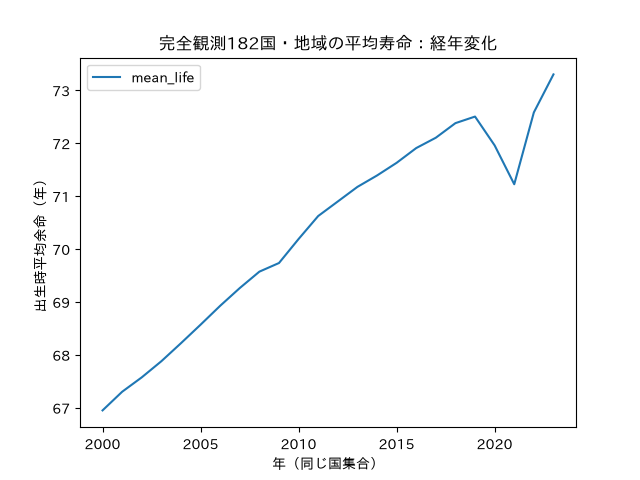

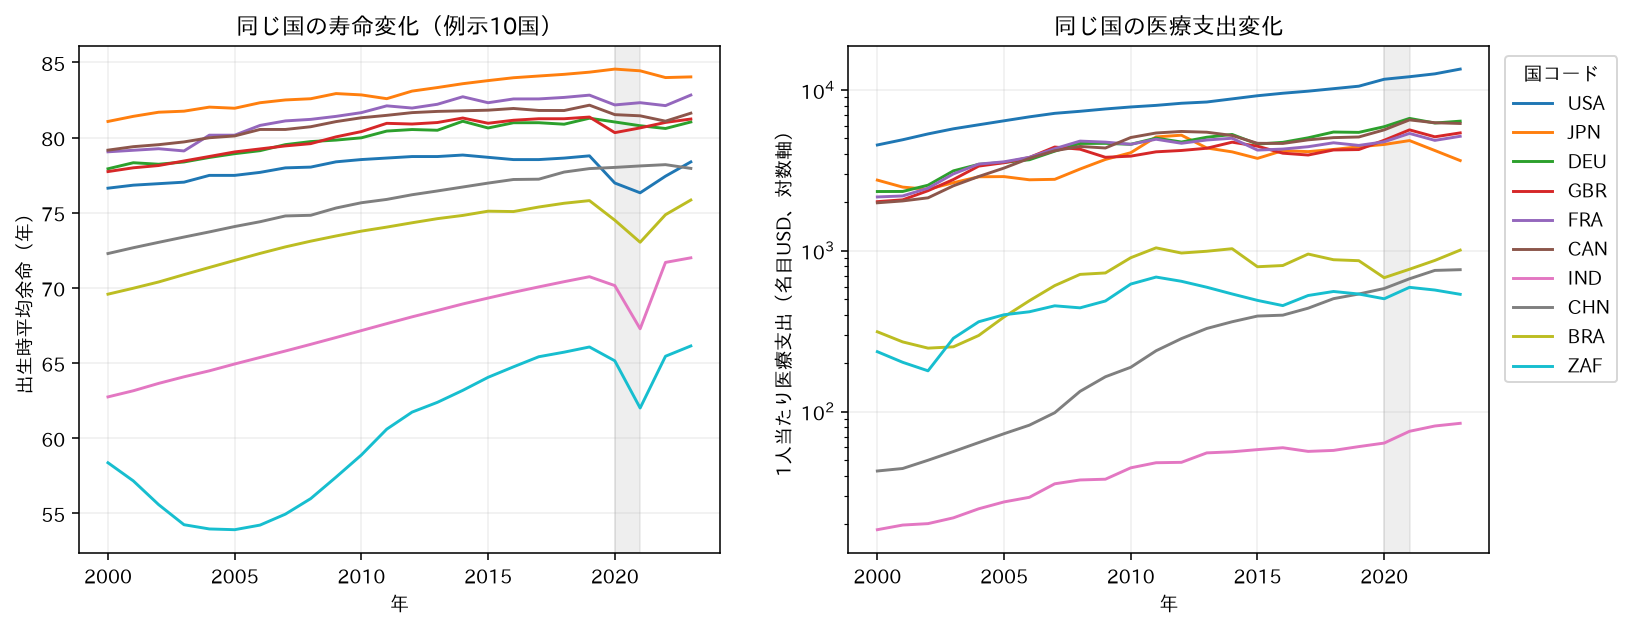

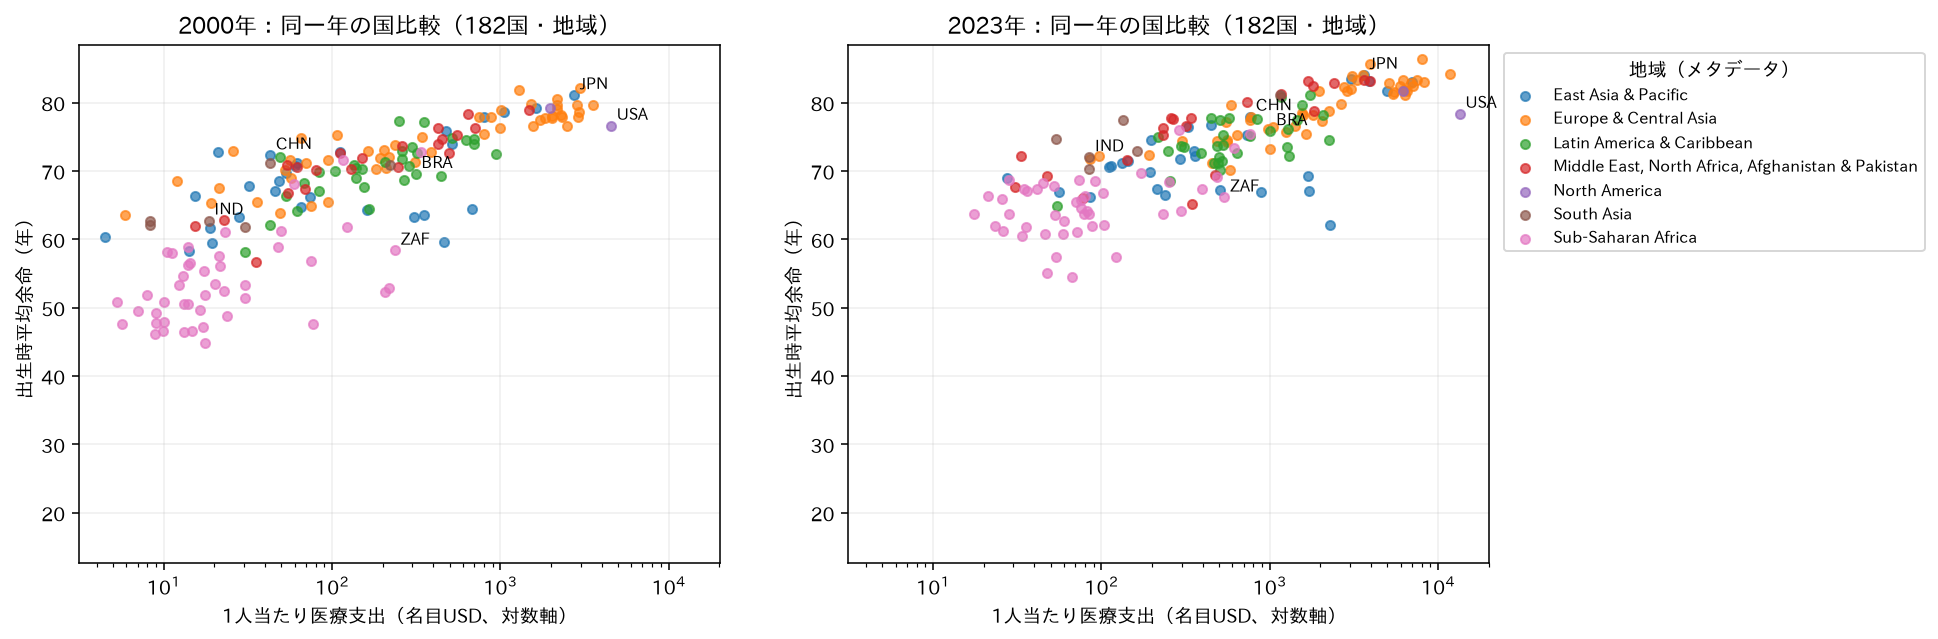

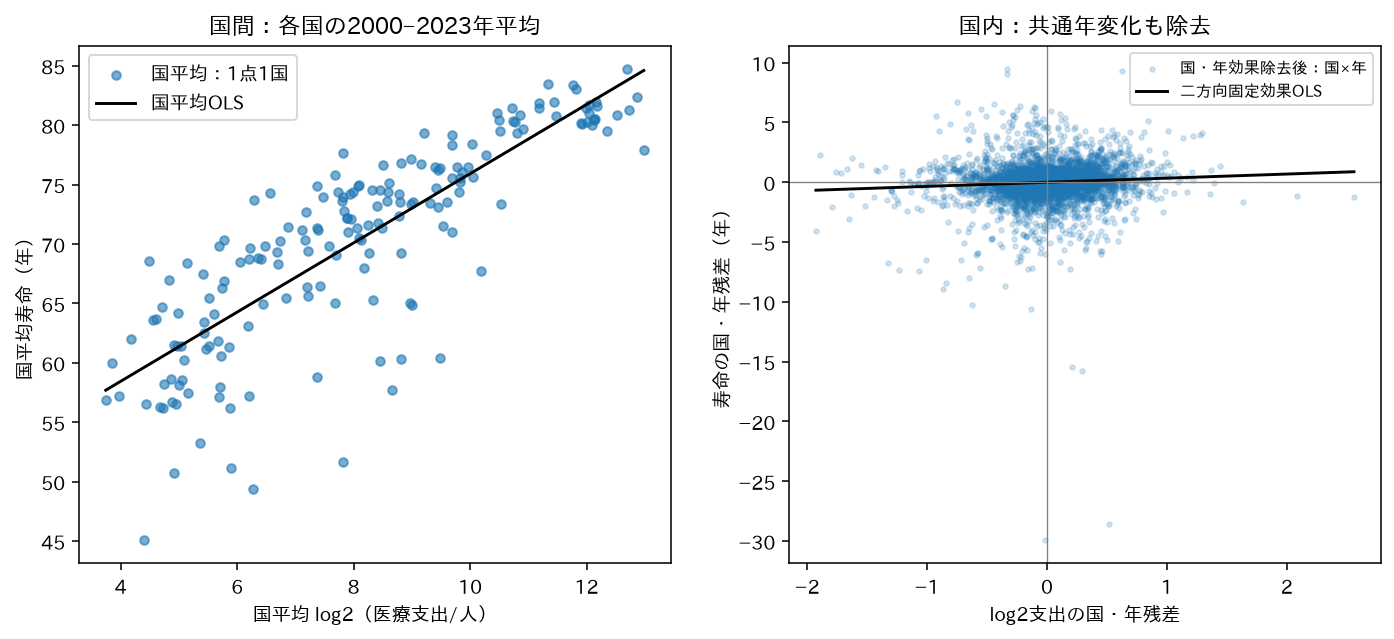

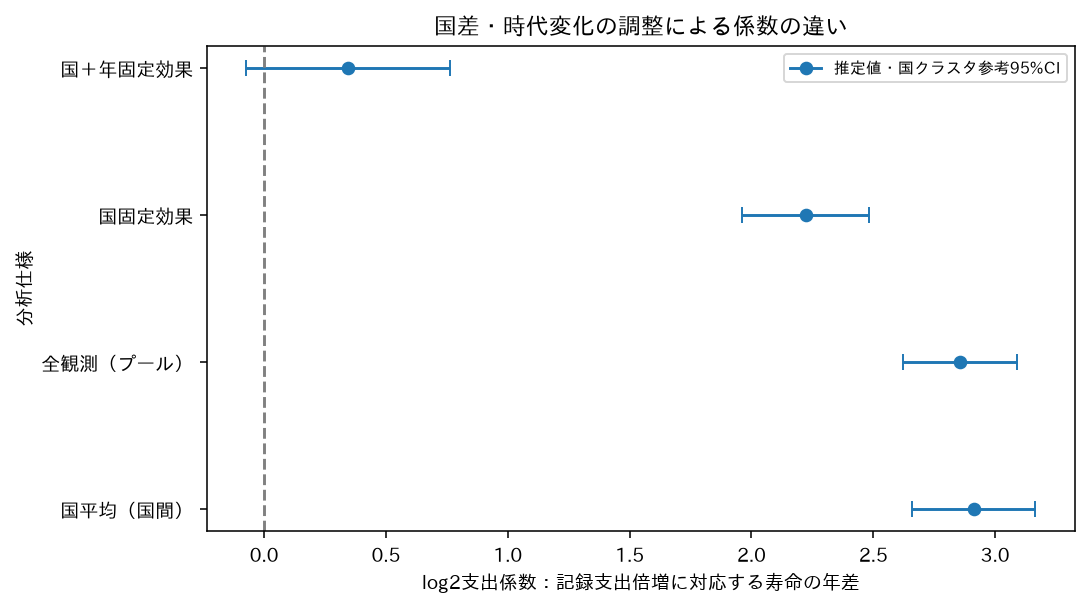

,country_code,country_name,life_2000,life_2023,spend_2000,spend_2023,life_change,spend_ratio
0,BRA,Brazil,69.584,75.848,313.926,1009.836,6.264,3.217
1,CAN,Canada,79.167,81.626,1988.159,6186.652,2.460,3.112
2,CHN,China,72.288,77.953,42.808,763.378,5.665,17.833
3,DEU,Germany,77.927,81.041,2336.362,6394.623,3.115,2.737
4,FRA,France,79.056,82.832,2161.853,5149.055,3.776,2.382
5,GBR,United Kingdom,77.741,81.238,2020.968,5407.170,3.497,2.676
6,IND,India,62.749,72.003,18.479,84.687,9.254,4.583
7,JPN,Japan,81.076,84.041,2751.385,3638.193,2.965,1.322
8,USA,United States,76.637,78.385,4548.555,13473.193,1.749,2.962
9,ZAF,South Africa,58.368,66.139,236.081,536.588,7.771,2.273


{'chart_records': [{'name': '01-fixed-country-time',
   'path': '/home/nahisaho/GitHub/jupytermind/benchmark/projects/kaggle-v020-kaggle-exp-20-healthexp/data/figures/01-fixed-country-time.png',
   'title': '完全観測国の平均寿命',
   'xlabel': '年',
   'ylabel': '出生時平均余命（年）',
   'legend': ['mean_life'],
   'missing_glyphs': [],
   'bytes': 34511},
  {'name': '02-country-trajectories',
   'path': '/home/nahisaho/GitHub/jupytermind/benchmark/projects/kaggle-v020-kaggle-exp-20-healthexp/data/figures/02-country-trajectories.png',
   'title': '国ごとの経年変化',
   'xlabel': '年',
   'ylabel': '寿命（年）/支出（名目USD）',
   'legend': ['USA',
    'JPN',
    'DEU',
    'GBR',
    'FRA',
    'CAN',
    'IND',
    'CHN',
    'BRA',
    'ZAF'],
   'missing_glyphs': [],
   'bytes': 162897},
  {'name': '03-same-year-country',
   'path': '/home/nahisaho/GitHub/jupytermind/benchmark/projects/kaggle-v020-kaggle-exp-20-healthexp/data/figures/03-same-year-country.png',
   'title': '2000年と2023年の同一年国比較',
   'xlabel': '支出（名目USD、対数軸）'

In [7]:
# 図表：時間変化と国差を別々に表示
import matplotlib.pyplot as plt
chart_records = []
figures_dir = data_dir / 'figures'
figures_dir.mkdir(exist_ok=True)
def show_png(png, name, title, xlabel, ylabel, legend, glyphs=None):
    path = figures_dir / (name+'.png')
    path.write_bytes(png)
    output = visualization.build_image_output(png)
    display(output['data'], raw=True)
    chart_records.append({'name':name,'path':str(path),'title':title,'xlabel':xlabel,'ylabel':ylabel,'legend':legend,'missing_glyphs':glyphs or [],'bytes':len(png)})
def show_figure(fig, name, title, xlabel, ylabel, legend):
    buffer = io.BytesIO()
    with warnings.catch_warnings(record=True) as caught:
        warnings.simplefilter('always')
        fig.savefig(buffer,format='png',dpi=140,bbox_inches='tight')
    glyphs = [str(w.message) for w in caught if 'Glyph' in str(w.message) and 'missing' in str(w.message)]
    plt.close(fig)
    show_png(buffer.getvalue(),name,title,xlabel,ylabel,legend,glyphs)
with phase('baseline_visualization'):
    with warnings.catch_warnings(record=True) as first_warnings:
        warnings.simplefilter('always')
        png = visualization.render_chart(year_summary.reset_index(),kind='line',x='year',y='mean_life',title='完全観測182国・地域の平均寿命：経年変化',xlabel='年（同じ国集合）',ylabel='出生時平均余命（年）')
    first_glyphs = [str(w.message) for w in first_warnings if 'Glyph' in str(w.message) and 'missing' in str(w.message)]
    show_png(png,'01-fixed-country-time','完全観測国の平均寿命','年','出生時平均余命（年）',['mean_life'],first_glyphs)
    focus_codes = ['USA','JPN','DEU','GBR','FRA','CAN','IND','CHN','BRA','ZAF']
    focus = panel.loc[panel.country_code.isin(focus_codes)]
    fig,axes = plt.subplots(1,2,figsize=(13,4.7))
    colors = dict(zip(focus_codes,plt.get_cmap('tab10').colors))
    for code in focus_codes:
        d = focus.loc[focus.country_code.eq(code)]
        axes[0].plot(d.year,d.life,label=code,color=colors[code])
        axes[1].plot(d.year,d.spend,label=code,color=colors[code])
    for ax in axes:
        ax.axvspan(2020,2021,color='grey',alpha=.13,label='_pandemic')
        ax.set_xlabel('年')
        ax.grid(alpha=.2)
    axes[0].set_title('同じ国の寿命変化（例示10国）'); axes[0].set_ylabel('出生時平均余命（年）')
    axes[1].set_title('同じ国の医療支出変化'); axes[1].set_ylabel('1人当たり医療支出（名目USD、対数軸）'); axes[1].set_yscale('log')
    axes[1].legend(loc='upper left',bbox_to_anchor=(1.01,1),title='国コード')
    show_figure(fig,'02-country-trajectories','国ごとの経年変化','年','寿命（年）/支出（名目USD）',focus_codes)
    fig,axes = plt.subplots(1,2,figsize=(13,4.8))
    for ax,year in zip(axes,[2000,2023]):
        d = panel.loc[panel.year.eq(year)]
        for region,group in d.groupby('region'):
            ax.scatter(group.spend,group.life,s=22,alpha=.7,label=region)
        for code in ['USA','JPN','CHN','IND','BRA','ZAF']:
            row = d.loc[d.country_code.eq(code)].iloc[0]
            ax.annotate(code,(row.spend,row.life),fontsize=8,xytext=(3,3),textcoords='offset points')
        ax.set_xlim(panel.spend.min()*.75,panel.spend.max()*1.5); ax.set_ylim(panel.life.min()-2,panel.life.max()+2)
        ax.set_xscale('log'); ax.set_title(f'{year}年：同一年の国比較（182国・地域）')
        ax.set_xlabel('1人当たり医療支出（名目USD、対数軸）'); ax.set_ylabel('出生時平均余命（年）'); ax.grid(alpha=.2)
    axes[1].legend(loc='upper left',bbox_to_anchor=(1.01,1),fontsize=8,title='地域（メタデータ）')
    show_figure(fig,'03-same-year-country','2000年と2023年の同一年国比較','支出（名目USD、対数軸）','出生時平均余命（年）',sorted(panel.region.unique()))
    fig,axes = plt.subplots(1,2,figsize=(12,4.8))
    axes[0].scatter(country_means.mean_log_spend,country_means.mean_life,s=20,alpha=.6,label='国平均：1点1国')
    bx = np.linspace(country_means.mean_log_spend.min(),country_means.mean_log_spend.max(),100)
    axes[0].plot(bx,country_means.mean_life.mean()+between_model['beta']*(bx-country_means.mean_log_spend.mean()),color='black',label='国平均OLS')
    axes[0].set_title('国間：各国の2000–2023年平均'); axes[0].set_xlabel('国平均 log2（医療支出/人）'); axes[0].set_ylabel('国平均寿命（年）'); axes[0].legend()
    axes[1].scatter(twoway_residuals.log_spend,twoway_residuals.life,s=6,alpha=.18,label='国・年効果除去後：国×年')
    bx = np.linspace(twoway_residuals.log_spend.min(),twoway_residuals.log_spend.max(),100)
    axes[1].plot(bx,models[-1]['beta']*bx,color='black',label='二方向固定効果OLS')
    axes[1].axhline(0,color='grey',lw=.7); axes[1].axvline(0,color='grey',lw=.7)
    axes[1].set_title('国内：共通年変化も除去'); axes[1].set_xlabel('log2支出の国・年残差'); axes[1].set_ylabel('寿命の国・年残差（年）'); axes[1].legend(fontsize=8)
    show_figure(fig,'04-between-vs-adjusted-within','国間と年調整後の国内関連','log2支出/残差','寿命（年）/残差',['国平均','固定効果残差','OLS'])
    fig,ax = plt.subplots(figsize=(8,4.5))
    names = ['国平均（国間）','全観測（プール）','国固定効果','国＋年固定効果']
    for i,row in model_table.iterrows():
        ax.errorbar(row.beta,i,xerr=[[row.beta-row.ci_low],[row.ci_high-row.beta]],fmt='o',color='C0',capsize=4)
    ax.set_yticks(range(4),names); ax.axvline(0,color='grey',ls='--'); ax.set_xlabel('log2支出係数：記録支出倍増に対応する寿命の年差'); ax.set_ylabel('分析仕様'); ax.set_title('国差・時代変化の調整による係数の違い')
    ax.plot([],[],marker='o',label='推定値・国クラスタ参考95%CI'); ax.legend(fontsize=8)
    show_figure(fig,'05-model-decomposition','固定効果仕様の比較','支出倍増に対応する年差','分析仕様',['推定値','国クラスタ参考95%CI'])
    country_change = panel.loc[panel.year.isin([2000,2023])].pivot(index=['country_code','country_name'],columns='year',values=['life','spend'])
    country_change.columns = [f'{variable}_{year}' for variable,year in country_change.columns]
    country_change['life_change'] = country_change.life_2023-country_change.life_2000
    country_change['spend_ratio'] = country_change.spend_2023/country_change.spend_2000
    focus_comparison = country_change.loc[country_change.index.get_level_values('country_code').isin(focus_codes)].reset_index()
display(focus_comparison.round(3))
{'chart_records':chart_records,'focus_comparison':focus_comparison.to_dict(orient='records'),'focus_selection_reason':'高所得6国と人口・地域の例示4国を事前選択。全対象を代表する無作為標本ではない。','mean_life_change_2000_2023':float(year_summary.loc[2023,'mean_life']-year_summary.loc[2000,'mean_life'])}


**国・年ごとの違い：図表と実数の読み取り**

同じ182国・地域集合の等重み平均寿命は2000年66.946年から2023年73.296年へ6.350年上昇した。2019年72.499、2020年71.954、2021年71.220と低下し、その後回復する。これは国平均の時代変化であり世界人口の重み付き平均ではなく、医療支出だけによる増加とも言えない。

2023年の例では、米国は1人当たり13,473USD・寿命78.385年、日本は3,638USD・84.041年。2000–2023年の米国は支出2.962倍・寿命+1.749年、日本は支出1.322倍・+2.965年。インドは支出4.583倍・+9.254年、中国は17.833倍・+5.665年。支出水準・伸び率と寿命水準・伸びは一対一に対応しない。

名目USD・為替・価格、医療以外の健康要因、初期寿命水準、制度、死亡ショックが異なるため、この比較から米国の医療の因果的非効率性や日本の制度の因果効果を断定しない。寿命/支出という比率を「効率」とするKaggleの派生列も採用しない。根拠は`baseline-charts`の国別実数表と図01–04。

```evidence
{"execution_count":7,"cited_value":"6.349691101581342","claim_type":"descriptive"}
```

In [8]:
# 感度分析：同じ推定対象尺度の二方向FEを12仕様で比較
with phase('baseline_sensitivity'):
    sensitivity_plan = sensitivity.SensitivityPlan(parameter_grid={'period':['full','pre2020','2010plus'], 'sample':['balanced','available'], 'exclude_usa':[False,True]},max_runs=12)
    def analyze_spec(period, sample, exclude_usa):
        d = panel if sample=='balanced' else eligible
        if period=='pre2020': d = d.loc[d.year.le(2019)]
        if period=='2010plus': d = d.loc[d.year.ge(2010)]
        if exclude_usa: d = d.loc[d.country_code.ne('USA')]
        return fit_panel(d,effects='twoway')['beta']
    sensitivity_report = sensitivity.run_sensitivity(sensitivity_plan,analyze_spec,stability_tolerance=.2)
    sensitivity_table = pd.DataFrame([dict(r.specification,beta=r.value) for r in sensitivity_report.results])
    raw_dollar_model = fit_panel(panel.assign(spend_thousand=panel.spend/1000),effects='twoway',exposure='spend_thousand')
    gdp_share_model = fit_panel(panel,effects='twoway',exposure='spend_gdp')
    stability_summary = {'stable':sensitivity_report.stable,'max_relative_deviation':sensitivity_report.max_relative_deviation,'baseline_value':sensitivity_report.baseline_value,'beta_min':float(sensitivity_table.beta.min()),'beta_max':float(sensitivity_table.beta.max()),'positive_specs':int(sensitivity_table.beta.gt(0).sum()),'runs':len(sensitivity_table),'tolerance':.2}
display(sensitivity_table.round(6))
{'stability_summary':stability_summary,'results':sensitivity_table.to_dict(orient='records'),'alternative_scale_raw_1000_usd':raw_dollar_model,'alternative_exposure_gdp_percentage_point':gdp_share_model,'comparison_warning':'生USDは1000USD増加、GDP比は1パーセントポイント増加であり、log2係数の倍増効果と大きさを直接比較しない。'}


,period,sample,exclude_usa,beta
0,full,balanced,False,0.343856
1,full,balanced,True,0.337168
2,full,available,False,0.331607
3,full,available,True,0.324835
4,pre2020,balanced,False,0.582353
5,pre2020,balanced,True,0.574756
6,pre2020,available,False,0.560669
7,pre2020,available,True,0.553033
8,2010plus,balanced,False,-0.387587
9,2010plus,balanced,True,-0.378864


{'stability_summary': {'stable': False,
  'max_relative_deviation': 2.1672357754893015,
  'baseline_value': 0.3438561388737783,
  'beta_min': -0.40136118691509165,
  'beta_max': 0.5823530092816784,
  'positive_specs': 8,
  'runs': 12,
  'tolerance': 0.2},
 'results': [{'period': 'full',
   'sample': 'balanced',
   'exclude_usa': False,
   'beta': 0.3438561388737783},
  {'period': 'full',
   'sample': 'balanced',
   'exclude_usa': True,
   'beta': 0.337167537565094},
  {'period': 'full',
   'sample': 'available',
   'exclude_usa': False,
   'beta': 0.3316071055740874},
  {'period': 'full',
   'sample': 'available',
   'exclude_usa': True,
   'beta': 0.32483451629638305},
  {'period': 'pre2020',
   'sample': 'balanced',
   'exclude_usa': False,
   'beta': 0.5823530092816784},
  {'period': 'pre2020',
   'sample': 'balanced',
   'exclude_usa': True,
   'beta': 0.5747561747989713},
  {'period': 'pre2020',
   'sample': 'available',
   'exclude_usa': False,
   'beta': 0.5606685923266118},
  {

**初回感度分析の解釈**

期間（全期間/2019年以前/2010年以降）、完全パネル/利用可能行、米国を含む/除くの12仕様。`stable=False`、最大相対偏差2.167（基準0.344に対する約217%）、係数範囲−0.401〜0.582。全期間で米国を除いても0.337、利用可能193国・地域へ広げても0.332なので、米国単独や完全パネル選択だけで主結果の小ささを説明できない。一方、2010年以降は負へ転じ、時期の影響が大きい。名目1000USD増加の仕様は−0.612年、GDP比1ポイント増加は−0.086年だが、尺度と推定対象が異なるので倍増係数と大きさを比較しない。正の国内関連が頑健とは述べない。

```evidence
{"execution_count":8,"cited_value":"2.1672357754893015","claim_type":"associational"}
```

# 反復依頼履歴

## 反復1：時期・所得交絡・極端な観測

**追加依頼文（原文）**

感度分析で2010年以降の係数が負に変わった理由を確かめてください。同じ国集合で2000–2009年、2010–2019年、2020–2023年を分け、GDP/人の変化を調整した仕様と未調整仕様を同一サンプルで比較してください。国・年残差が極端な観測と前年比の大きな寿命変化を特定し、可能なら世界銀行の上流APIに照合して、データ誤りと実際のショックを区別してください。ショックを除いた感度は誤り訂正ではなく別の対象と明記してください。

**選定理由**：初回12仕様で符号反転、残差図に約−30年の極端値。単純な「正の関係」という結論を変え得るため。上流APIはKaggleデータの代替取得ではなく、定義・加工整合性の確認。共通の世界銀行出典なので独立の観測証拠とは呼ばない。

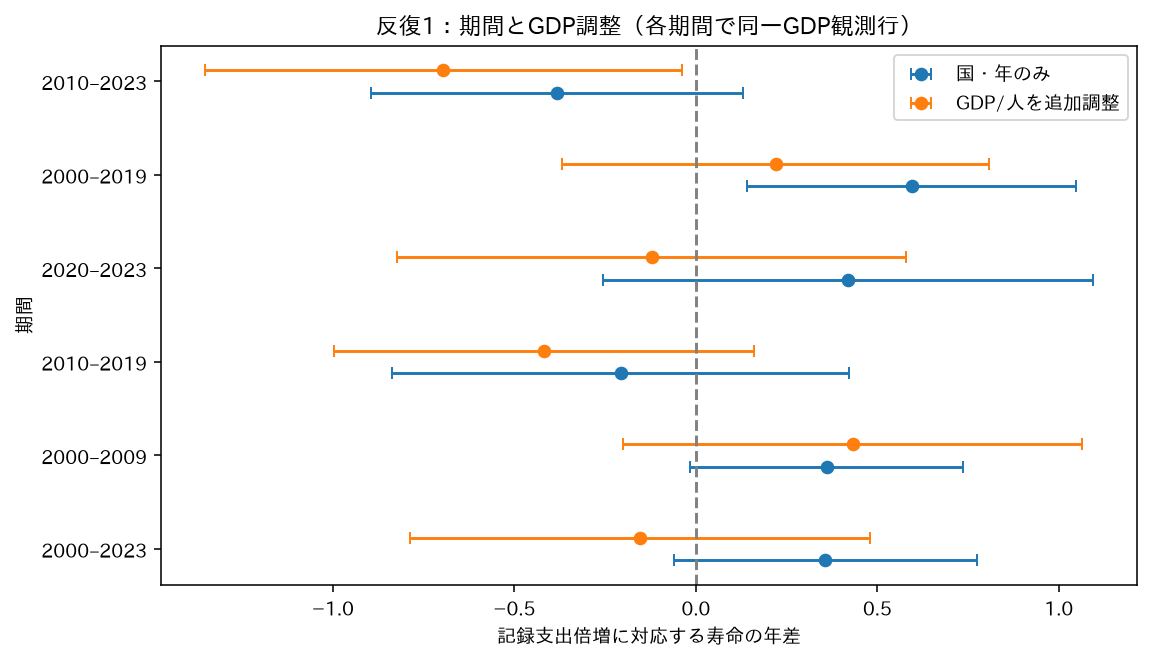

,period,model,beta,ci_low,ci_high,n,countries,gdp_beta
0,2000–2023,twoway,0.35642,-0.06165,0.77449,4350,182,NaN
1,2000–2023,twoway_gdp,-0.15502,-0.78881,0.47878,4350,182,0.75270
2,2000–2009,twoway,0.36024,-0.01653,0.73702,1820,182,NaN
3,2000–2009,twoway_gdp,0.43170,-0.20138,1.06479,1820,182,-0.11310
4,2010–2019,twoway,-0.20759,-0.83727,0.42209,1811,182,NaN
5,2010–2019,twoway_gdp,-0.41897,-0.99678,0.15884,1811,182,0.37952
6,2020–2023,twoway,0.41882,-0.25643,1.09406,719,180,NaN
7,2020–2023,twoway_gdp,-0.12189,-0.82276,0.57898,719,180,1.47589
8,2000–2019,twoway,0.59457,0.14211,1.04702,3631,182,NaN
9,2000–2019,twoway_gdp,0.21992,-0.36823,0.80807,3631,182,0.54957


,country_code,country_name,year,life,delta_life,life_fe_residual,spend
657,CAF,Central African Republic,2009,14.665,-35.208,-29.872,21.378
670,CAF,Central African Republic,2022,18.818,-21.461,-28.565,47.915
667,CAF,Central African Republic,2019,31.530,-20.767,-15.775,35.761
1738,HTI,Haiti,2010,45.577,-16.117,-15.450,55.735
3335,PSE,West Bank and Gaza,2023,65.170,-11.492,-10.616,345.680
3408,RWA,Rwanda,2000,47.798,NaN,-10.264,9.004
2696,MMR,Myanmar,2008,56.364,-6.003,-6.482,14.708
662,CAF,Central African Republic,2014,40.265,-9.222,-5.926,18.712
669,CAF,Central African Republic,2021,40.279,-10.317,-5.747,46.250
2303,LBY,Libya,2023,69.339,-5.123,-5.364,470.403


{'period_results': [{'model': 'twoway',
   'exposure': 'log_spend',
   'beta': 0.3564202739589778,
   'se_country_cluster': 0.21187978241677494,
   'ci_low': -0.06165181080783211,
   'ci_high': 0.7744923587257877,
   'n': 4350,
   'countries': 182,
   'years': 24,
   'df_total': 206,
   'gdp_beta': nan,
   'period': '2000–2023'},
  {'model': 'twoway_gdp',
   'exposure': 'log_spend',
   'beta': -0.15501767050494358,
   'se_country_cluster': 0.32120917904679974,
   'ci_low': -0.7888138241472988,
   'ci_high': 0.4787784831374116,
   'n': 4350,
   'countries': 182,
   'years': 24,
   'df_total': 207,
   'gdp_beta': 0.7527045804542026,
   'period': '2000–2023'},
  {'model': 'twoway',
   'exposure': 'log_spend',
   'beta': 0.36024378408056135,
   'se_country_cluster': 0.19094873242192872,
   'ci_low': -0.01652805198913232,
   'ci_high': 0.737015620150255,
   'n': 1820,
   'countries': 182,
   'years': 10,
   'df_total': 192,
   'gdp_beta': nan,
   'period': '2000–2009'},
  {'model': 'twoway_

In [9]:
# 反復1：期間分割・GDP調整・ショック点検・上流照合
from urllib.request import Request, urlopen
from urllib.error import URLError, HTTPError
from ai_data_scientist import dataset_validation
reference_events = []
reference_provenance = []
reference_comparison = None
metadata_api = {}
with phase('iteration1'):
    matched_gdp = panel.loc[panel.log_gdp.notna()].copy()
    period_models = []
    for label,start,end in [('2000–2023',2000,2023),('2000–2009',2000,2009),('2010–2019',2010,2019),('2020–2023',2020,2023),('2000–2019',2000,2019),('2010–2023',2010,2023)]:
        d = matched_gdp.loc[matched_gdp.year.between(start,end)]
        for adjust in [False,True]:
            period_models.append(dict(fit_panel(d,adjust_gdp=adjust),period=label))
    period_table = pd.DataFrame(period_models)
    shock_data = panel.copy()
    shock_data['delta_life'] = shock_data.groupby('country_code').life.diff()
    shock_data['life_fe_residual'] = twoway_residuals.life.to_numpy()
    shocks = shock_data.loc[shock_data.delta_life.abs().gt(5) | shock_data.life_fe_residual.abs().gt(10), ['country_code','country_name','year','life','delta_life','life_fe_residual','spend']].sort_values('life_fe_residual')
    shock_codes = sorted(shocks.country_code.unique())
    def public_json(url, filename):
        try:
            request = Request(url,headers={'User-Agent':'Jupytermind-public-data-validation/1.0'})
            with urlopen(request,timeout=45) as response:
                payload = response.read(12_000_001)
            if len(payload)>12_000_000:
                raise ValueError('参照APIの応答が上限を超えた')
            data = json.loads(payload)
            local = data_dir / filename
            local.write_bytes(payload)
            reference_provenance.append({'url':url,'filename':filename,'retrieved_at_utc':datetime.now(timezone.utc).isoformat(),'sha256':hashlib.sha256(payload).hexdigest(),'relationship':'共通上流出典、独立観測ではない'})
            reference_events.append({'url':url,'status':'ok'})
            return data
        except (HTTPError,URLError,TimeoutError,OSError,ValueError) as exc:
            reference_events.append({'url':url,'status':'failed','error_type':type(exc).__name__,'http_status':getattr(exc,'code',None)})
            return None
    for indicator in ['SP.DYN.LE00.IN','SH.XPD.CHEX.PC.CD']:
        url = 'https://api.worldbank.org/v2/indicator/'+indicator+'?format=json'
        response = public_json(url,'worldbank-definition-'+indicator+'.json')
        if response and len(response)>1:
            metadata_api[indicator] = response[1][0]
    if shock_codes:
        url = 'https://api.worldbank.org/v2/country/'+';'.join(shock_codes)+'/indicator/SP.DYN.LE00.IN?date=2000:2023&format=json&per_page=20000'
        response = public_json(url,'worldbank-shock-life-reference.json')
        if response and len(response)>1 and isinstance(response[1],list):
            assert int(response[0]['pages']) == 1, '参照APIのページ欠落'
            reference = pd.DataFrame([{'country_code':r['countryiso3code'],'year':int(r['date']),'life':r['value']} for r in response[1] if r['value'] is not None])
            primary_shock_countries = panel.loc[panel.country_code.isin(shock_codes),['country_code','year','life']]
            reference_comparison = dataset_validation.compare_datasets(primary_shock_countries,reference,key_mapping={'country_code':'country_code','year':'year'},value_mapping={'life':'life'},candidate_relationship='overlapping')
            reference_join = primary_shock_countries.merge(reference,on=['country_code','year'],suffixes=('_kaggle','_worldbank'),validate='one_to_one')
            reference_join['absolute_difference'] = (reference_join.life_kaggle-reference_join.life_worldbank).abs()
            reference_summary = {'matched_rows':len(reference_join),'max_absolute_difference':float(reference_join.absolute_difference.max()),'within_1e_6_rate':float(reference_join.absolute_difference.le(1e-6).mean())}
        else:
            reference_summary = {'verification':'未実施。上流API取得失敗であり、極端値が誤りでないと断定できない。'}
    else:
        reference_summary = {'verification':'閾値を超える観測なし'}
    shock_sensitivity = [dict(fit_panel(panel),specification='all_observations'), dict(fit_panel(panel.loc[~panel.index.isin(shocks.index)]),specification='exclude_flagged_years'), dict(fit_panel(panel.loc[~panel.country_code.isin(shock_codes)]),specification='exclude_flagged_countries')]
    variables_verified = {key:dict(value) for key,value in definition_manifest.variables.items()}
    if 'SH.XPD.CHEX.PC.CD' in metadata_api:
        note = metadata_api['SH.XPD.CHEX.PC.CD'].get('sourceNote','')
        variables_verified['spend']['unit'] = data_definition.FieldValue(metadata_api['SH.XPD.CHEX.PC.CD'].get('name'),'verified','World Bank indicator API')
        variables_verified['spend']['official_definition'] = data_definition.FieldValue(note,'verified','World Bank indicator API')
        if 'capital' in note.lower():
            variables_verified['spend']['capital_inclusion'] = data_definition.FieldValue('資本支出を含まない（公式sourceNote）','verified','World Bank indicator API')
    if 'SP.DYN.LE00.IN' in metadata_api:
        variables_verified['life']['official_definition'] = data_definition.FieldValue(metadata_api['SP.DYN.LE00.IN'].get('sourceNote'),'verified','World Bank indicator API')
    definition_manifest = data_definition.build_manifest(definition_manifest.source,definition_manifest.dataset_scope,variables_verified,definition_manifest.transformations)
    fig,ax = plt.subplots(figsize=(9,5))
    for adjust,offset,color in [(False,-.12,'C0'),(True,.12,'C1')]:
        d = period_table.loc[period_table.model.eq('twoway_gdp' if adjust else 'twoway')]
        y = np.arange(len(d))+offset
        ax.errorbar(d.beta,y,xerr=[d.beta-d.ci_low,d.ci_high-d.beta],fmt='o',color=color,capsize=3,label='GDP/人を追加調整' if adjust else '国・年のみ')
    ax.set_yticks(range(6),period_table.period.unique()); ax.axvline(0,color='grey',ls='--')
    ax.set_title('反復1：期間とGDP調整（各期間で同一GDP観測行）'); ax.set_xlabel('記録支出倍増に対応する寿命の年差'); ax.set_ylabel('期間'); ax.legend()
    show_figure(fig,'06-period-gdp','期間・GDP調整の比較','支出倍増に対応する年差','期間',['国・年のみ','GDP/人追加調整'])
display(period_table[['period','model','beta','ci_low','ci_high','n','countries','gdp_beta']].round(5))
display(shocks.round(3))
{'period_results':period_table.to_dict(orient='records'),'shock_codes':shock_codes,'shock_sensitivity':shock_sensitivity,'reference_comparison':asdict(reference_comparison) if reference_comparison else None,'reference_summary':reference_summary,'reference_events':reference_events,'reference_provenance':reference_provenance,'official_definitions':{k:{field:v.get(field) for field in ['name','sourceNote','sourceOrganization']} for k,v in metadata_api.items()},'remaining_definition_unknowns':[(p,asdict(v)) for p,v in definition_manifest.unresolved_fields()]}


**反復1の結果・証拠・残る限界**

GDPが観測された同一4,350行では、国＋年係数0.356がGDP/人追加調整で−0.155（参考CI −0.789〜0.479）へ変わる。2010–2019年だけでも未調整−0.208であり、2010年以降の負の係数をCOVID期だけで説明することはできない。GDP自体も内生的・潜在的媒介変数なので、追加調整を「交絡除去が完了した因果効果」とは呼ばない。

前年比絶対差>5年または国・年残差絶対値>10年の25観測・13国を検出。特に中央アフリカ共和国の2009年14.665、2022年18.818等は精査が必要。これら13国×24年312行の寿命は世界銀行APIの同名指標と完全一致（最大絶対差0）。これはKaggleで新たに発生した転記誤りの証拠がないことを示すだけで、上流の推計の正確性や実際のショック原因を独立検証したわけではない。異常を自動で真値・誤りと分類しない。

全観測0.344、該当年除外0.363、該当13国除外0.267。除外後もCIは0を含む。除外は誤り訂正ではなく対象範囲を変える感度分析で、主結果は全観測を維持。公式APIで「current US$」と出生時平均余命の期間定義を確認した。資本支出の扱い等はなお未確認。

**残る限界**：国固有の長期トレンド、支出のラグ、所得以外の交絡、上流の極端値の推計過程は未解決。証拠は`iteration-1`の期間表・25観測一覧・API照合manifest・図06。

```evidence
{"execution_count":9,"cited_value":"0.0","claim_type":"associational"}
```

# 反復依頼履歴（続き）

## 反復2：国固有トレンド・短期変化・ラグ

**追加依頼文（原文）**

GDP調整と時期分割でも国内関連が安定しないため、国固有の緩やかな寿命トレンドと短期変化を区別してください。国・年固定効果に国別線形トレンドを追加した仕様、連続年の一階差分、1年・3年ラグの支出を比較し、同じサンプルでの同時点係数も示してください。未来の支出との関連は診断用途に限定し、ラグだけで因果性が成立するとは述べないでください。固定効果計算は小さな部分標本で明示的ダミーOLSと一致するか検証してください。

**選定理由**：GDP調整で係数が変化し、2010–2019年にも負の関連がある。時期の違いをCOVIDだけで説明できず、国別ドリフトと同時性を追加点検する価値がある。

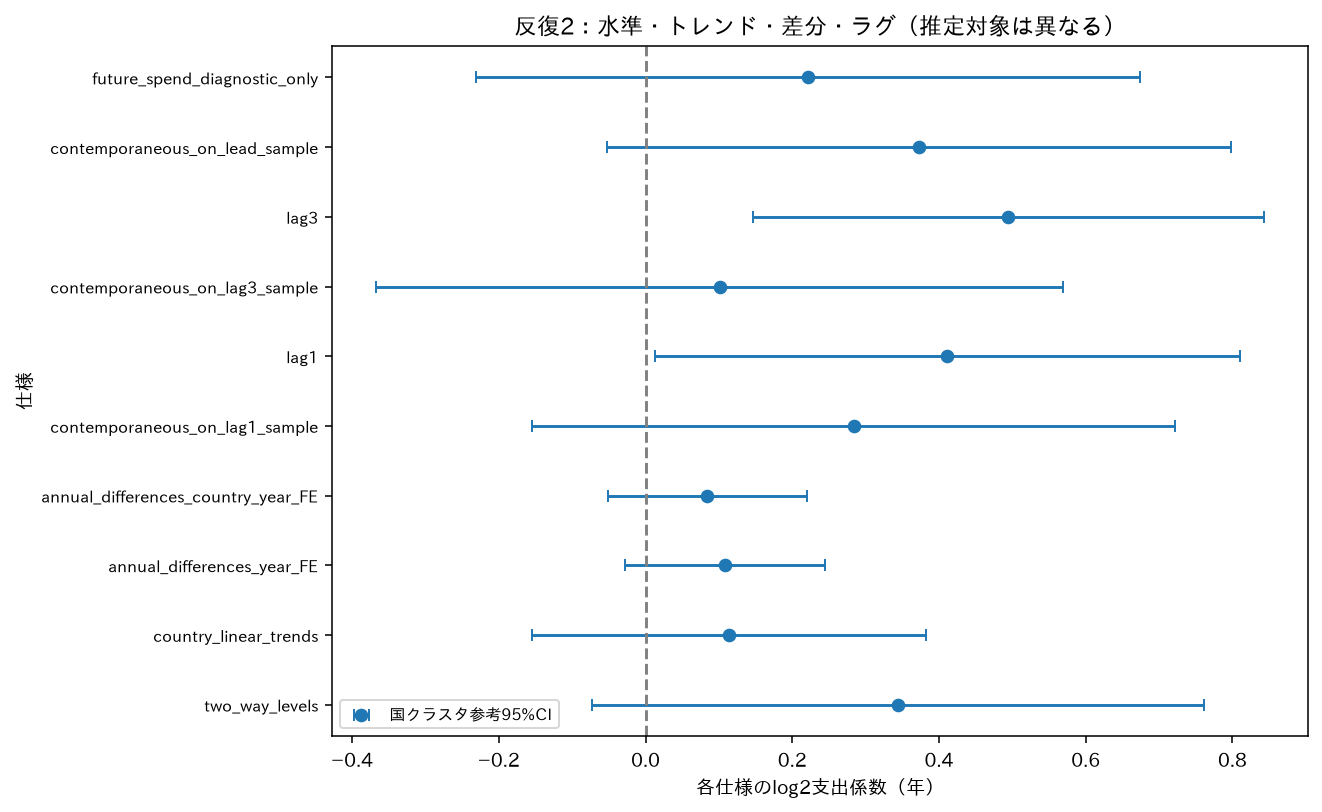

,specification,beta,ci_low,ci_high,n
0,two_way_levels,0.34386,-0.07321,0.76093,4368
1,country_linear_trends,0.11399,-0.15428,0.38225,4368
2,annual_differences_year_FE,0.10842,-0.02792,0.24476,4186
3,annual_differences_country_year_FE,0.08399,-0.05182,0.21981,4186
4,contemporaneous_on_lag1_sample,0.28359,-0.15431,0.72148,4186
5,lag1,0.41154,0.01258,0.81050,4186
6,contemporaneous_on_lag3_sample,0.10110,-0.36712,0.56932,3822
7,lag3,0.49441,0.14584,0.84298,3822
8,contemporaneous_on_lead_sample,0.37307,-0.05229,0.79844,4186
9,future_spend_diagnostic_only,0.22081,-0.23174,0.67335,4186


{'dynamic_results': [{'model': 'twoway',
   'exposure': 'log_spend',
   'beta': 0.3438561388737783,
   'se_country_cluster': 0.2113713661253969,
   'ci_low': -0.07321276070735055,
   'ci_high': 0.7609250384549071,
   'n': 4368,
   'countries': 182,
   'years': 24.0,
   'df_total': 206.0,
   'gdp_beta': nan,
   'specification': 'two_way_levels'},
  {'model': 'country_trends_plus_year',
   'exposure': nan,
   'beta': 0.11398824402035729,
   'se_country_cluster': 0.13595798972541084,
   'ci_low': -0.15427822084413972,
   'ci_high': 0.3822547088848543,
   'n': 4368,
   'countries': 182,
   'years': nan,
   'df_total': nan,
   'gdp_beta': nan,
   'specification': 'country_linear_trends'},
  {'model': 'first_difference_plus_year',
   'exposure': nan,
   'beta': 0.10841682520413466,
   'se_country_cluster': 0.06909647730255186,
   'ci_low': -0.02792137557378606,
   'ci_high': 0.2447550259820554,
   'n': 4186,
   'countries': 182,
   'years': nan,
   'df_total': nan,
   'gdp_beta': nan,
   'sp

In [10]:
# 反復2：国別トレンド・差分・ラグ・推定計算の検証
with phase('iteration2'):
    def detrend_country(data, columns):
        z = data[columns].astype(float).copy()
        z -= z.groupby(data.country_code).transform('mean')
        t = data.year-data.groupby('country_code').year.transform('mean')
        denom = (t*t).groupby(data.country_code).transform('sum')
        if denom.le(0).any():
            raise ValueError('国別トレンドには2年以上が必要')
        numerator = z.mul(t,axis=0).groupby(data.country_code).transform('sum')
        return z-numerator.div(denom,axis=0).mul(t,axis=0)
    def residualize_trends(data, columns):
        z = data[columns].astype(float).copy()
        t = data.year-data.groupby('country_code').year.transform('mean')
        denom = (t*t).groupby(data.country_code).transform('sum')
        for iteration in range(1000):
            old = z.to_numpy().copy()
            z -= z.groupby(data.country_code).transform('mean')
            slope = z.mul(t,axis=0).groupby(data.country_code).transform('sum').div(denom,axis=0)
            z -= slope.mul(t,axis=0)
            z -= z.groupby(data.year).transform('mean')
            if np.max(np.abs(z.to_numpy()-old))<1e-10:
                return z
        raise RuntimeError('国別トレンド射影が収束しない')
    def clustered_residual_fit(data,z,exposure,nuisance_rank,label):
        x = z[exposure].to_numpy(); y = z.life.to_numpy()
        xx = float(x@x)
        if xx<=0: raise ValueError('説明変数の残差分散がない')
        beta = float(x@y/xx); residual = y-beta*x
        score = pd.Series(x*residual).groupby(data.country_code.reset_index(drop=True)).sum()
        n,g = len(data),data.country_code.nunique()
        k = nuisance_rank+1
        variance = g/(g-1)*(n-1)/(n-k)*float(score@score)/(xx*xx)
        se = np.sqrt(variance); crit = scipy_stats.t.ppf(.975,g-1)
        return {'model':label,'beta':beta,'se_country_cluster':float(se),'ci_low':float(beta-crit*se),'ci_high':float(beta+crit*se),'n':n,'countries':g}
    trend_z = residualize_trends(panel,['life','log_spend'])
    trend_model = clustered_residual_fit(panel,trend_z,'log_spend',2*panel.country_code.nunique()+panel.year.nunique()-2,'country_trends_plus_year')
    differences = panel.copy()
    differences['delta_year'] = differences.groupby('country_code').year.diff()
    differences['life'] = differences.groupby('country_code').life.diff()
    differences['log_spend'] = differences.groupby('country_code').log_spend.diff()
    differences = differences.loc[differences.delta_year.eq(1)].reset_index(drop=True)
    diff_z = differences[['life','log_spend']]-differences.groupby('year')[['life','log_spend']].transform('mean')
    diff_model = clustered_residual_fit(differences,diff_z,'log_spend',differences.year.nunique(),'first_difference_plus_year')
    diff_country_model = fit_panel(differences,effects='twoway')
    lag_models = []
    for lag in [1,3]:
        d = panel.copy()
        d['lag_log_spend'] = d.groupby('country_code').log_spend.shift(lag)
        d = d.dropna(subset=['lag_log_spend'])
        lag_models.append(dict(fit_panel(d,exposure='log_spend'),specification=f'contemporaneous_on_lag{lag}_sample'))
        lag_models.append(dict(fit_panel(d,exposure='lag_log_spend'),specification=f'lag{lag}'))
    lead = panel.copy()
    lead['lead_log_spend'] = lead.groupby('country_code').log_spend.shift(-1)
    lead = lead.dropna(subset=['lead_log_spend'])
    lag_models.append(dict(fit_panel(lead,exposure='log_spend'),specification='contemporaneous_on_lead_sample'))
    lag_models.append(dict(fit_panel(lead,exposure='lead_log_spend'),specification='future_spend_diagnostic_only'))
    dynamic_table = pd.DataFrame([dict(models[-1],specification='two_way_levels'),dict(trend_model,specification='country_linear_trends'),dict(diff_model,specification='annual_differences_year_FE'),dict(diff_country_model,specification='annual_differences_country_year_FE')]+lag_models)
    small = panel.loc[panel.country_code.isin(focus_codes)].reset_index(drop=True)
    def dummy_beta(d,trend=False):
        c = pd.get_dummies(d.country_code,drop_first=True,dtype=float)
        yr = pd.get_dummies(d.year,drop_first=True,dtype=float)
        design = pd.concat([pd.Series(1.,index=d.index,name='intercept'),d.log_spend,c,yr],axis=1)
        if trend:
            full_c = pd.get_dummies(d.country_code,dtype=float)
            design = pd.concat([design,full_c.mul(d.year-d.year.mean(),axis=0)],axis=1)
        beta = np.linalg.lstsq(design.to_numpy(),d.life.to_numpy(),rcond=None)[0]
        return float(beta[1]),int(np.linalg.matrix_rank(design.to_numpy()))
    dummy_plain,rank_plain = dummy_beta(small)
    fe_plain = fit_panel(small)['beta']
    small_z = residualize_trends(small,['life','log_spend'])
    fe_trend = float(small_z.log_spend@small_z.life/(small_z.log_spend@small_z.log_spend))
    dummy_trend,rank_trend = dummy_beta(small,trend=True)
    unbalanced_small = small.drop(index=small.index[::17]).reset_index(drop=True)
    dummy_unbalanced,_ = dummy_beta(unbalanced_small)
    fe_unbalanced = fit_panel(unbalanced_small)['beta']
    estimator_checks = {'plain_abs_difference':abs(dummy_plain-fe_plain),'trend_abs_difference':abs(dummy_trend-fe_trend),'unbalanced_abs_difference':abs(dummy_unbalanced-fe_unbalanced),'plain_rank':rank_plain,'trend_rank':rank_trend,'n':len(small)}
    assert max(estimator_checks[k] for k in ['plain_abs_difference','trend_abs_difference','unbalanced_abs_difference'])<1e-8
    assert rank_plain == small.country_code.nunique()+small.year.nunique()
    assert rank_trend == 2*small.country_code.nunique()+small.year.nunique()-1
    fig,ax = plt.subplots(figsize=(9,6.4))
    d = dynamic_table
    ax.errorbar(d.beta,np.arange(len(d)),xerr=[d.beta-d.ci_low,d.ci_high-d.beta],fmt='o',capsize=3,label='国クラスタ参考95%CI')
    ax.set_yticks(np.arange(len(d)),d.specification,fontsize=8); ax.axvline(0,color='grey',ls='--')
    ax.set_title('反復2：水準・トレンド・差分・ラグ（推定対象は異なる）'); ax.set_xlabel('各仕様のlog2支出係数（年）'); ax.set_ylabel('仕様'); ax.legend(fontsize=8)
    show_figure(fig,'07-trend-differences-lags','トレンド・差分・ラグ','各仕様のlog2係数（年）','仕様',['推定値','国クラスタ参考95%CI'])
display(dynamic_table[['specification','beta','ci_low','ci_high','n']].round(5))
{'dynamic_results':dynamic_table.to_dict(orient='records'),'trend_beta':trend_model['beta'],'difference_beta':diff_model['beta'],'estimator_checks':estimator_checks,'interpretation_constraint':'差分と水準は異なる推定対象。ラグは支出の外生性を保証せず、未来支出診断も正式な因果検定ではない。'}


**反復2の結果・証拠・残る限界**

国別線形トレンド＋年効果の係数0.114（参考CI −0.154〜0.382）、年効果付き一階差分0.108（−0.028〜0.245）、差分に国効果も追加0.084（−0.052〜0.220）。短期の国内関連が明確・安定に正とは言えない。

一方、1年ラグ0.412（0.013〜0.811）、3年ラグ0.494（0.146〜0.843）は正。対応する同一サンプルの同時点係数は0.284と0.101。ラグは疫学的にあり得るが、支出の強い自己相関・国別トレンド・所得変化・複数仕様探索があるため、遅れて効く因果効果の証拠としては不十分。未来支出診断0.221（−0.232〜0.673）も正式な負の対照ではなく、0を含むことは外生性を証明しない。

小部分標本10国×24年で、二方向FE・国別トレンド・不均衡パネルの係数が明示的ダミーOLSと最大2.1e−13の差で一致。計算実装の違いが主要な係数変化を生んだという証拠はない。証拠は`iteration-2`の10仕様表・計算照合出力・図07。

**残る限界**：正のラグ係数はGDP・国別トレンド未調整であり、最終結論に実質的に影響する未解決点。差分は誤差を増幅し、国別トレンドは緩やかな真の支出効果まで取り除き得る。

```evidence
{"execution_count":10,"cited_value":"0.11398824402035729","claim_type":"associational"}
```

# 反復依頼履歴（続き）

## 反復3：正のラグ結果の頑健性

**追加依頼文（原文）**

反復2で正になった1年・3年ラグ係数が結論を変えるか確認してください。各ラグについてGDP/人と国・年効果を調整し、さらに国別線形トレンドを加えた場合も、全期間と2019年以前で比較してください。各仕様と同一行の同時点係数を併記し、ラグの選択・多重探索・共通トレンドへの依存を評価してください。結果が不安定なら、正のラグだけを選んだ因果結論を避けてください。

**選定理由**：反復2で1年・3年ラグのCIが正の範囲となり、「国内関連が弱い」という結論を変える可能性がある。追加調整と同一サンプルの対照で確かめる。

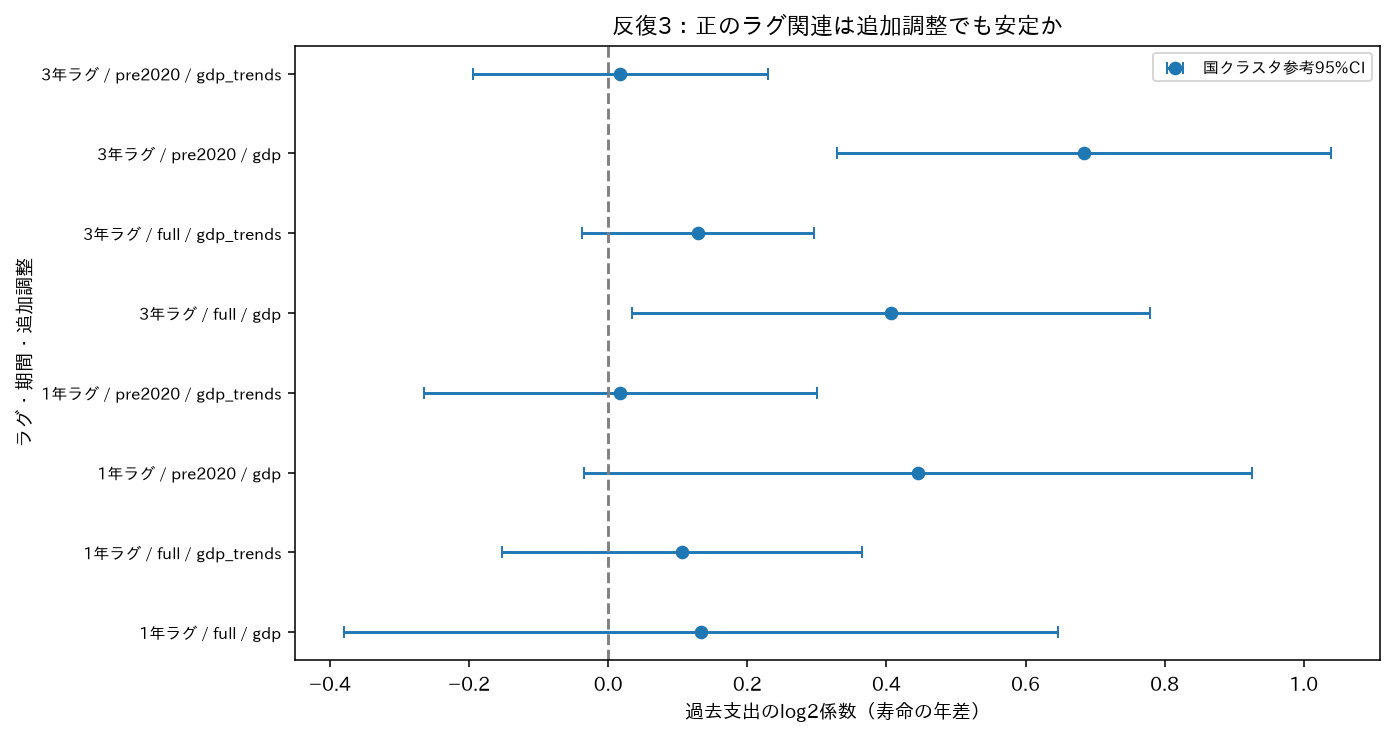

,lag,period,adjustment,timing,beta,ci_low,ci_high,n
0,1,full,gdp,lag,0.13345,-0.37963,0.64654,4168
1,1,full,gdp,same_sample_current,-0.21280,-0.84557,0.41998,4168
2,1,full,gdp_trends,lag,0.10602,-0.15306,0.36510,4168
3,1,full,gdp_trends,same_sample_current,0.08223,-0.26030,0.42476,4168
4,1,pre2020,gdp,lag,0.44532,-0.03492,0.92556,3449
5,1,pre2020,gdp,same_sample_current,0.18453,-0.40093,0.76999,3449
6,1,pre2020,gdp_trends,lag,0.01747,-0.26508,0.30003,3449
7,1,pre2020,gdp_trends,same_sample_current,-0.01217,-0.37457,0.35022,3449
8,3,full,gdp,lag,0.40698,0.03493,0.77902,3804
9,3,full,gdp,same_sample_current,-0.41263,-1.03239,0.20712,3804


{'refined_lag_summary': {'stable': False,
  'max_relative_deviation': 4.124252124325299,
  'baseline_value': 0.13345237713512803,
  'min': 0.017474363709308462,
  'max': 0.6838436270309407,
  'runs': 8,
  'positive_ci_count': 2},
 'lag_results': [{'model': 'twoway_gdp',
   'exposure': 'lag_log_spend',
   'beta': 0.13345237713512803,
   'se_country_cluster': 0.2600335166050027,
   'ci_low': -0.37963458735144373,
   'ci_high': 0.6465393416216998,
   'n': 4168,
   'countries': 182,
   'years': 23.0,
   'df_total': 206.0,
   'gdp_beta': 0.49139049318976763,
   'lag': 1,
   'period': 'full',
   'adjustment': 'gdp',
   'timing': 'lag',
   'standardized_condition_number': nan},
  {'model': 'twoway_gdp',
   'exposure': 'log_spend',
   'beta': -0.21279547324477843,
   'se_country_cluster': 0.3206898369541751,
   'ci_low': -0.8455668833797816,
   'ci_high': 0.4199759368902247,
   'n': 4168,
   'countries': 182,
   'years': 23.0,
   'df_total': 206.0,
   'gdp_beta': 0.7521109690022644,
   'lag': 

In [11]:
# 反復3：ラグ関連のGDP・国固有トレンド調整
with phase('iteration3'):
    def fit_trend_multiple(data, exposure):
        xs = [exposure,'log_gdp']
        d = data.dropna(subset=['life']+xs).reset_index(drop=True)
        z = residualize_trends(d,['life']+xs)
        x = z[xs].to_numpy(); y = z.life.to_numpy()
        beta,_,rank,_ = np.linalg.lstsq(x,y,rcond=None)
        assert rank == len(xs), 'トレンド調整説明変数がランク落ち'
        residual = y-x@beta
        scores = pd.DataFrame(x*residual[:,None]).groupby(d.country_code).sum().to_numpy()
        bread = np.linalg.inv(x.T@x)
        n,g,t = len(d),d.country_code.nunique(),d.year.nunique()
        k = 2*g+t-2+len(xs)
        cov = g/(g-1)*(n-1)/(n-k)*(bread@(scores.T@scores)@bread)
        se = np.sqrt(max(float(cov[0,0]),0)); crit = scipy_stats.t.ppf(.975,g-1)
        scaled_x = x/np.sqrt((x*x).sum(axis=0))
        return {'model':'gdp_country_trends_year','beta':float(beta[0]),'ci_low':float(beta[0]-crit*se),'ci_high':float(beta[0]+crit*se),'n':n,'countries':g,'gdp_beta':float(beta[1]),'standardized_condition_number':float(np.linalg.cond(scaled_x))}
    lag_refinement = []
    for lag in [1,3]:
        d = panel.copy()
        d['lag_log_spend'] = d.groupby('country_code').log_spend.shift(lag)
        d = d.dropna(subset=['lag_log_spend','log_gdp'])
        for period in ['full','pre2020']:
            subset = d if period=='full' else d.loc[d.year.le(2019)]
            for adjustment in ['gdp','gdp_trends']:
                for timing,exposure in [('lag','lag_log_spend'),('same_sample_current','log_spend')]:
                    result = fit_panel(subset,exposure=exposure,adjust_gdp=True) if adjustment=='gdp' else fit_trend_multiple(subset,exposure)
                    lag_refinement.append(dict(result,lag=lag,period=period,adjustment=adjustment,timing=timing))
    lag_refinement_table = pd.DataFrame(lag_refinement)
    lag_plan = sensitivity.SensitivityPlan({'lag':[1,3],'period':['full','pre2020'],'adjustment':['gdp','gdp_trends']},max_runs=8)
    def refined_lag_value(lag,period,adjustment):
        row = lag_refinement_table.loc[lag_refinement_table.lag.eq(lag)&lag_refinement_table.period.eq(period)&lag_refinement_table.adjustment.eq(adjustment)&lag_refinement_table.timing.eq('lag')]
        assert len(row)==1
        return float(row.beta.iloc[0])
    refined_sensitivity = sensitivity.run_sensitivity(lag_plan,refined_lag_value,stability_tolerance=.2)
    refined_summary = {'stable':refined_sensitivity.stable,'max_relative_deviation':refined_sensitivity.max_relative_deviation,'baseline_value':refined_sensitivity.baseline_value,'min':min(r.value for r in refined_sensitivity.results),'max':max(r.value for r in refined_sensitivity.results),'runs':len(refined_sensitivity.results),'positive_ci_count':int(((lag_refinement_table.timing=='lag')&(lag_refinement_table.ci_low>0)).sum())}
    fig,ax = plt.subplots(figsize=(10,5.7))
    lag_only = lag_refinement_table.loc[lag_refinement_table.timing.eq('lag')].reset_index(drop=True)
    labels = [f'{r.lag}年ラグ / {r.period} / {r.adjustment}' for r in lag_only.itertuples()]
    ax.errorbar(lag_only.beta,np.arange(len(lag_only)),xerr=[lag_only.beta-lag_only.ci_low,lag_only.ci_high-lag_only.beta],fmt='o',capsize=3,label='国クラスタ参考95%CI')
    ax.set_yticks(np.arange(len(lag_only)),labels,fontsize=8); ax.axvline(0,color='grey',ls='--')
    ax.set_title('反復3：正のラグ関連は追加調整でも安定か'); ax.set_xlabel('過去支出のlog2係数（寿命の年差）'); ax.set_ylabel('ラグ・期間・追加調整'); ax.legend(fontsize=8)
    show_figure(fig,'08-refined-lag-sensitivity','GDP・トレンド調整後のラグ','過去支出log2係数（年）','仕様',['推定値','国クラスタ参考95%CI'])
display(lag_refinement_table[['lag','period','adjustment','timing','beta','ci_low','ci_high','n']].round(5))
{'refined_lag_summary':refined_summary,'lag_results':lag_refinement_table.to_dict(orient='records'),'exploration_warning':'事後の8ラグ仕様は確認的検定ではない。係数の最大/最小・符号と全仕様を報告し、有意な仕様だけを採用しない。トレンド追加で変わることも因果効果ゼロの証明ではない。'}


**反復3の結果・証拠・残る限界**

1年ラグはGDP追加調整で0.133、さらに国別トレンドで0.106（参考CI −0.153〜0.365）。3年ラグはGDP調整のみでは全期間0.407、2019年以前0.684だが、国別トレンドも追加すると全期間0.129（−0.038〜0.296）、2019年以前0.018（−0.195〜0.230）へ縮小。

8ラグ仕様の`stable=False`、最大相対偏差4.124（基準0.133に対し約412%）、範囲0.017〜0.684。方向は全仕様で正だが大きさは不安定で、国別トレンド調整後の全4仕様はCIが0を含む。全仕様を報告し、正のCIとなった2仕様だけを選択しない。調整後の標準化説明変数の条件数は概ね1.14〜2.10で、明らかなランク落ちは検出されなかった。

**証拠**：`iteration-3`の16行対照表、8仕様SensitivityReport、図08。**残る限界**：国別トレンドは真の緩やかな効果まで取り除き得るため、係数縮小は効果ゼロの証明ではない。名目USD、観測データ、未観測の行動・制度・人口構成、逆因果、複数仕様探索を残す。

**反復終了**：結論に実質的に影響した時期・所得・異常値・トレンド・ラグを3回で点検した。これ以上の同じデータの仕様探索は選択的報告のリスクを増やし、因果識別に新しい価値を与えにくい。上限3回に達したため終了。未解決点を「解決済み」とはせず、PPP/実質支出、独立した死亡推計、制度変更等の識別戦略が必要と記録する。

```evidence
{"execution_count":11,"cited_value":"4.124252124325299","claim_type":"associational"}
```

# 使用したJupytermindモジュール

以下は本NotebookのコードセルおよびJupyter MCPによる記録セルで**直接import・呼出し**したもの。間接依存は使用済みに数えない。`ai_data_scientist`はJupytermindのPythonパッケージ名。

| モジュール | 直接呼出した関数・クラス・メソッド | 使用目的 |
|---|---|---|
| `ai_data_scientist.project_manager` | `resolve_project`, `ensure_notebook`, `ensure_data_dir`, `enqueue_write`, `ProjectHandle` | 保存先と安定パス、書込み直列化、監査用合成fixture |
| `ai_data_scientist.language_router` | `detect_language` | 日本語の検出 |
| `ai_data_scientist.lifecycle` | `register_run`, `mark_execution_start/end`, `mark_write_start/end`, `is_cancel_requested`, `mark_completed`, `mark_failed`, `get_run_status`, `wait_for_quiescence` | 実行/書込みログと終了状態 |
| `ai_data_scientist.ingestion` | `SourceSpec`, `ingest` | Kaggle取得CSVの読み込み・行上限の確認 |
| `ai_data_scientist.cleaning` | `clean_dataset` | complete case除外の行・列影響の報告 |
| `ai_data_scientist.eda` | `explore` | 型・欠損・要約統計 |
| `ai_data_scientist.stats_analysis` | `correlation` | Pearson相関と日本語解釈 |
| `ai_data_scientist.data_definition` | `FieldValue`, `build_manifest`, `DataDefinitionManifest.unresolved_fields` | 定義とverified/inferred/unknownの分離 |
| `ai_data_scientist.analysis_assumptions` | `Assumption`, `AnalysisAssumptionManifest`, `check_manifest` | 観測上の関連と因果の区別・全finding報告 |
| `ai_data_scientist.data_quality` | `detect_anomalies` | 意味的範囲・null・カテゴリ検査 |
| `ai_data_scientist.sensitivity` | `SensitivityPlan`, `run_sensitivity` | 有限予算内の12仕様・ラグ8仕様評価 |
| `ai_data_scientist.dataset_validation` | `compare_datasets` | 共通上流APIとのキー・値照合。`overlapping`であり独立性を主張しない |
| `ai_data_scientist.visualization` | `render_chart`, `build_image_output` | 日本語字体設定・図PNG生成・MIME出力 |
| `ai_data_scientist.insight_engine` | `extract_cited_value`, `record_insight` | 実出力から引用値抽出・根拠付き結論の記録・再実行後の更新 |
| `ai_data_scientist.notebook_audit` | `audit_notebook` | `visual_audit=True`監査と合成fixtureの再現 |

`mcp_gateway`、`anomaly_detection`、`dataset_validation`のデータ探索機能（存在しない）、ML各モジュールは使用済みと数えない。統計上のzスコアだけで真偽を決めない。分析用のpandas/numpy/scipy/matplotlib、Kaggle SDK、urllib、IPython、nbformatはJupytermindモジュールではない。非適用の詳細は`final-summary`出力のapplicabilityに記録。


In [12]:
# Jupytermind改善候補の最小再現（分析データと合成監査fixtureを区別）
with phase('module_diagnostics'):
    parsed_na_rows = int(raw.loc[raw.country_name.eq('Namibia'),'country_code'].isna().sum())
    preserved_na_rows = int(raw_preserved.loc[raw_preserved.country_name.eq('Namibia'),'country_code'].eq('NA').sum())
    fixture_path = data_dir / 'audit-metadata-repro.ipynb'
    fixture_handle = pm.ProjectHandle(name=handle.name,root=handle.root,notebook_path=fixture_path,data_dir=data_dir)
    lifecycle.mark_write_start(RUN_ID)
    try:
        pm.ensure_notebook(fixture_handle)
        def fixture_mutation(nb):
            image_cell = nbformat.v4.new_code_cell('# 合成fixture：既存画像を監査入力に用いる（実行の根拠ではない）',execution_count=1)
            image_cell.outputs = [visualization.build_image_output((figures_dir/'01-fixed-country-time.png').read_bytes())]
            image_cell.outputs[0].execution_count = 1
            nb.cells = [image_cell,nbformat.v4.new_markdown_cell('## 合成の結論\n根拠manifestがない、このfixtureは分析結論ではない。')]
        pm.enqueue_write(fixture_handle,fixture_mutation)
    finally:
        lifecycle.mark_write_end(RUN_ID)
    fixture_report = notebook_audit.audit_notebook(fixture_path,visual_audit=True)
    diagnostic_evidence = {'csv_Namibia_default_null_rows':parsed_na_rows,'csv_Namibia_preserved_NA_rows':preserved_na_rows,'ingest_signature':str(inspect.signature(ingestion.ingest)),'synthetic_audit_fixture':asdict(fixture_report),'synthetic_audit_ok':fixture_report.ok,'expected_fixture_findings':['missing_chart_metadata','missing_glyph_check_metadata','headed_insight_without_evidence'],'actual_fixture_findings':[asdict(f) for f in fixture_report.findings]}
    fixture_path.unlink()
{'diagnostic_evidence':diagnostic_evidence,'scope':'合成fixtureは不具合再現のみ。主Notebookの図表metadataと根拠manifestを省略してよいことを意味しない。','separation':'上流CSVのISO2/ISO3誤結合・極端な推計値は公開データ側。初回国名ソートTypeErrorは分析コード側。SDK検索・取得は成功。CLI/ベンチマークランナー固有障害は今回なし。'}


{'diagnostic_evidence': {'csv_Namibia_default_null_rows': 65,
  'csv_Namibia_preserved_NA_rows': 65,
  'ingest_signature': "(source_spec: 'SourceSpec', fetcher=None, allowlist: 'tuple[str, ...]' = (), row_limit: 'int' = 100000) -> 'IngestionResult'",
  'synthetic_audit_fixture': {'path': '/home/nahisaho/GitHub/jupytermind/benchmark/projects/kaggle-v020-kaggle-exp-20-healthexp/data/audit-metadata-repro.ipynb',
   'nbformat_valid': True,
   'code_cell_count': 1,
   'executed_code_cell_count': 1,
   'unexecuted_cell_indices': (),
   'error_cell_indices': (),
   'chart_cell_indices': (0,),
   'insight_cell_count': 0,
   'findings': (),
   'visual_findings': ()},
  'synthetic_audit_ok': True,
  'expected_fixture_findings': ['missing_chart_metadata',
   'missing_glyph_check_metadata',
   'headed_insight_without_evidence'],
  'actual_fixture_findings': []},
 'scope': '合成fixtureは不具合再現のみ。主Notebookの図表metadataと根拠manifestを省略してよいことを意味しない。',
 'separation': '上流CSVのISO2/ISO3誤結合・極端な推計値は公開データ側。初回国名ソートTy

# Jupytermind改善候補

候補は以下の3件。ソース変更・GitHub Issue登録は本分析の範囲外。`module-diagnostics`で機密情報を含まない最小再現と実ログを保存。分析結果の欠落や失敗を隠すために監査を弱めていない。

| ID / 分類 | 再現条件 | 期待する挙動 | 実際の挙動 | 影響 | 回避策 | 関連セル・ログ |
|---|---|---|---|---|---|---|
| JM-20-01 / 取込の機能不足 | `ingestion.ingest(SourceSpec('csv',health_panel))`のISO2値`NA`（Namibia） | CSV列のdtype/NA規則を指定し、正当なカテゴリを保持できる | `pd.read_csv`既定により65行がnull化。ingest APIにreader kwargsがない | 国の欠落・キー誤照合 | Jupyterセル内で`pd.read_csv(keep_default_na=False,na_values=[''])`を使い、欠損とNAを区別しISO2一意照合 | `ingestion`, `quality-manifests`, `module-diagnostics`; null=65 / preserved=65 |
| JM-20-02 / 図表監査の検出不足 | PNGあり、`metadata.chart`とglyph検査記録なしの合成fixtureを`visual_audit=True`で監査 | metadata/glyph検査が未実施と検出する | metadataがないとラベル/字体不足を報告しない | 監査okでも図が読めることを保証しない | 主Notebookは全PNGのタイトル/軸/凡例・save時字体警告を明示登録し、出力画像も目視。最終セルでmetadata完全性を別assert | `module-diagnostics`のsynthetic_audit_fixture、`baseline-charts`、`final-audit` |
| JM-20-03 / 根拠監査の検出不足 | `##`から始まる結論markdownで根拠manifestなしの合成fixture | 見出し付き結論にも根拠確認が働く | 見出しで始まるmarkdownはinsight候補から除外 | 根拠欠落・古い参照を見逃し得る | 根拠付き結果セルは冒頭を太字にし、全evidence fenceを見出し有無によらず最終セルで検証 | `module-diagnostics`のsynthetic_audit_ok/actual_fixture_findings、`final-audit` |

**切り分け**：Kaggle公開CSVのISO2/ISO3誤結合（region全欠損）・欠損国名・上流の極端な寿命推計はデータ提供側でありJupytermind不具合と数えない。初回国名ソート`TypeError`は分析者の前提不一致で、一意ISO2結合へ修正・再実行した。Kaggle認証・検索・取得は成功。保存先ディレクトリ未作成での初回Jupyter MCP `use_notebook(create)`失敗はMCP接続準備の問題で、`ensure_notebook`により解消。Copilot CLI・Kaggle API・ベンチマークランナー固有の未解決問題はなし。


In [13]:
# 最終manifest・追跡可能な結論値と非適用理由
with phase('final_summary'):
    definition_variables = {k:dict(v) for k,v in definition_manifest.variables.items()}
    if 'SP.DYN.LE00.IN' in metadata_api:
        definition_variables['life']['measurement_pathway'] = data_definition.FieldValue('当該年の死亡率パターンが持続すると仮定した出生時平均余命。コホート追跡寿命ではない','verified','World Bank indicator API sourceNote')
    if 'SH.XPD.CHEX.PC.CD' in metadata_api:
        definition_variables['spend']['price_adjustment'] = data_definition.FieldValue('current US$。PPP・インフレ調整指標ではない','verified','World Bank indicator API name/sourceNote')
    definition_manifest = data_definition.build_manifest(definition_manifest.source,definition_manifest.dataset_scope,definition_variables,definition_manifest.transformations)
    unknowns_final = [(p,asdict(v)) for p,v in definition_manifest.unresolved_fields()]
    inferred_final = [(f'{var}.{key}',asdict(v)) for var,fields in definition_manifest.variables.items() for key,v in fields.items() if v.status=='inferred']
    final_assumptions = analysis_assumptions.AnalysisAssumptionManifest(analysis_scope=assumption_manifest.analysis_scope,assumptions=assumption_manifest.assumptions + (
        analysis_assumptions.Assumption('estimator-equivalence','小標本でFE・トレンド・不均衡係数がダミーOLSと一致','tested',impact_if_false='計算誤り',conclusion_critical=True),
        analysis_assumptions.Assumption('stable-positive-within','国内係数の符号・大きさが期間と追加調整で安定する','rejected',impact_if_false='頑健な正の国内関連とは主張できない',conclusion_critical=True),
        analysis_assumptions.Assumption('upstream-check','ショック13国312行は共通上流APIと一致','verified',impact_if_false='Kaggle加工誤りの可能性',conclusion_critical=False)
    ),causal_scope='associational',sampling=assumption_manifest.sampling)
    final_assumption_findings = analysis_assumptions.check_manifest(final_assumptions)
    final_results = {'run_id':RUN_ID,'source_slug':selected_slug,'fallback_used':False,'period':[2000,2023],'countries_territories':panel.country_code.nunique(),'n':len(panel),'pooled_log_pearson':pooled_corr.statistic,'between_log_pearson':between_corr.statistic,'twoway_residual_correlation':r_twoway,'twoway_beta':models[-1]['beta'],'twoway_ci':[models[-1]['ci_low'],models[-1]['ci_high']],'country_trend_beta':trend_model['beta'],'country_trend_ci':[trend_model['ci_low'],trend_model['ci_high']],'mean_life_change':float(year_summary.loc[2023,'mean_life']-year_summary.loc[2000,'mean_life']),'sensitivity':stability_summary,'refined_lag_sensitivity':refined_summary,'reference_check':reference_summary,'iteration_count':3}
    applicability = {'causal_identification':'非適用：無作為化・外生制度変更・妥当な操作変数等なし。因果主張をしない。','independent_validation':'非適用：World Bank APIは同じ上流で独立観測でない。validate_anomaliesによる独立データ平均検証は実施しない。compare_datasetsはoverlappingとして加工整合性だけ確認。','1960_1999_spend_relation':'非適用：支出欠損。寿命だけで支出係数を推定しない。','2024_main_analysis':'非適用：国別支出は22国のみ。欠損を補間せず2000–2023を主分析。','sampling_ml':'非適用：予測やMLが目的でなく、全適格行を記述する。学習/テスト分割・AutoML・SHAP等は使わない。','mcp_gateway.run_and_record':'非適用：このホストが提供するJupyter MCP execute_cellで直接実行して実出力を保存。同一カーネルからMCP再呼出しを行う偽クライアントやローカルexecで代用しない。','Kaggle_fallback':'非適用：Kaggle APIで対象CSVの取得に成功したため、旧実験CSVは取得・利用しない。','sensitivity_budget':'12仕様とラグ8仕様は各max_runs内。別推定尺度の生USD/GDP比や差分を倍増係数の安定性計算へ混入させない。'}
    public_manifest = {'source_files':provenance,'reference_files':reference_provenance,'data_definition':asdict(definition_manifest),'analysis_assumptions':asdict(final_assumptions),'assumption_findings':[asdict(f) for f in final_assumption_findings],'quality':selection_report,'applicability':applicability,'results':final_results}
    (data_dir/'analysis-manifest.json').write_text(json.dumps(public_manifest,ensure_ascii=False,indent=2,default=str),encoding='utf-8')
display(pd.DataFrame([asdict(f) for f in final_assumption_findings]))
{'final_results':final_results,'unknown_definition_fields':unknowns_final,'inferred_definition_fields':inferred_final,'assumption_findings':[asdict(f) for f in final_assumption_findings],'applicability':applicability,'analysis_manifest_path':str(data_dir/'analysis-manifest.json')}


,code,severity,message,assumption_id
0,unresolved_conclusion_critical_assumption,warning,Conclusion-critical assumption 'complete-case-...,complete-case-target
1,unresolved_conclusion_critical_assumption,warning,Conclusion-critical assumption 'stable-prices'...,stable-prices
2,unresolved_conclusion_critical_assumption,warning,Conclusion-critical assumption 'log-linearity'...,log-linearity
3,unresolved_conclusion_critical_assumption,warning,Conclusion-critical assumption 'cluster-indepe...,cluster-independence
4,unresolved_conclusion_critical_assumption,warning,Conclusion-critical assumption 'stable-positiv...,stable-positive-within


{'final_results': {'run_id': 'v020-exp-20',
  'source_slug': 'belbino/life-expectancy-healthcare-spending-1960-present',
  'fallback_used': False,
  'period': [2000, 2023],
  'countries_territories': 182,
  'n': 4368,
  'pooled_log_pearson': 0.8102639455020482,
  'between_log_pearson': 0.826250395576429,
  'twoway_residual_correlation': 0.07462098834967719,
  'twoway_beta': 0.3438561388737783,
  'twoway_ci': [-0.07321276070735055, 0.7609250384549071],
  'country_trend_beta': 0.11398824402035729,
  'country_trend_ci': [-0.15427822084413972, 0.3822547088848543],
  'mean_life_change': 6.349691101581342,
  'sensitivity': {'stable': False,
   'max_relative_deviation': 2.1672357754893015,
   'baseline_value': 0.3438561388737783,
   'beta_min': -0.40136118691509165,
   'beta_max': 0.5823530092816784,
   'positive_specs': 8,
   'runs': 12,
   'tolerance': 0.2},
  'refined_lag_sensitivity': {'stable': False,
   'max_relative_deviation': 4.124252124325299,
   'baseline_value': 0.1334523771351280

# 結論と因果推論の限界

**主結論**：医療支出が多い国ほど平均寿命が長い傾向がある。ただし、国差を除き、さらに年共通変化・所得・国別トレンドを調整すると国内関連は弱く、期間・ラグ・金額尺度によって変化する。「支出を倍にすると寿命が何年延びる」という因果効果は、この観測データでは識別できない。

所得・教育・衛生・医療制度・健康行動・喫煙・食事・環境・人口構成・感染症・紛争等は支出と寿命の双方に関係する。健康悪化が支出を増やす逆因果、長寿化が医療需要を変える同時性、支出価格と為替も残る。年効果が除くのは共通平均変化だけで、国別のCOVID影響等を完全に除去しない。GDP調整は潜在的媒介経路まで調整する可能性がある。

完全観測国・地域は欠損国を無作為に代表せず、等国重みは世界人口の平均ではない。国集計の関連を個人の支出・寿命へ適用しない（生態学的誤謬）。寿命の期間指標、名目USD、上流の極端な推計、独立死亡データ不在、多重仕様探索、国クラスタ間の相関可能性も制約として残す。参考CIの0包含/非包含を、効果ゼロの証明/因果効果の証明としない。

数値の根拠・6件のevidence manifest・8図は各実行セルと隣接する解釈に示した。最終コードセルは全コードセルの上からの再実行後に、ファイルSHA-256、数値再現、全根拠参照、図表metadata、`notebook_audit(visual_audit=True)`、lifecycleを検証して記録する。


In [ ]:
# 最終監査：根拠再接続・図表metadata・再実行一致・ライフサイクル
with phase('notebook_audit'):
    saved = nbformat.read(handle.notebook_path,as_version=4)
    expected = saved.metadata['initial_analysis_snapshot']
    data_hashes = {name:hashlib.sha256((stage/name).read_bytes()).hexdigest() for name in expected['data_sha256']}
    assert data_hashes == expected['data_sha256'], '再取得ファイルが初回と異なる。固定結論の再確認が必要'
    assert len(panel)==expected['results']['n'] and panel.country_code.nunique()==expected['results']['countries']
    numerical_replay = {'twoway_beta':abs(models[-1]['beta']-expected['results']['twoway_beta']),'trend_beta':abs(trend_model['beta']-expected['results']['trend_beta']),'refined_max_deviation':abs(refined_summary['max_relative_deviation']-expected['results']['refined_max_deviation'])}
    assert max(numerical_replay.values())<1e-10, '初回分析との数値不一致'
    templates = [(c.id,c.metadata.copy(),c.source.split('\n\n```evidence',1)[0]) for c in saved.cells if c.metadata.get('evidence_source_cell_id')]
    for original_id,meta,text in templates:
        current = nbformat.read(handle.notebook_path,as_version=4)
        evidence_cell = next(c for c in current.cells if c.id==meta['evidence_source_cell_id'])
        actual = '\n'.join(str(o.get('data',{}).get('text/plain','')) for o in evidence_cell.outputs)
        cited = insight_engine.extract_cited_value({'output':actual},meta['evidence_pattern'])
        assert evidence_cell.execution_count is not None and not any(o.output_type=='error' for o in evidence_cell.outputs)
        lifecycle.mark_write_start(RUN_ID)
        log_phase('evidence','write_start')
        try:
            insight_engine.record_insight(handle,text,evidence_cell.execution_count,cited,'descriptive' if meta['evidence_source_cell_id']=='baseline-charts' else 'associational',language='ja')
        finally:
            lifecycle.mark_write_end(RUN_ID)
            log_phase('evidence','write_end')
        def relocate(nb):
            replacement = nb.cells.pop()
            index = next(i for i,c in enumerate(nb.cells) if c.id==original_id)
            replacement.id = original_id
            replacement.metadata.update(meta)
            nb.cells[index] = replacement
        queued_write(relocate)
    def attach_chart_metadata(nb):
        mapping = {'baseline-charts':chart_records[:5],'iteration-1':chart_records[5:6],'iteration-2':chart_records[6:7],'iteration-3':chart_records[7:8]}
        for cell_id,records in mapping.items():
            cell = next(c for c in nb.cells if c.id==cell_id)
            images = [o for o in cell.outputs if 'image/png' in o.get('data',{})]
            assert len(images)==len(records)>0
            for record in records:
                assert record['title'] and record['xlabel'] and record['ylabel'] and record['legend']
                assert record['missing_glyphs']==[], 'PNGに文字欠落を検出'
            cell.metadata['chart'] = {'title':' / '.join(r['title'] for r in records),'xlabel':' / '.join(r['xlabel'] for r in records),'ylabel':' / '.join(r['ylabel'] for r in records),'legend':[item for r in records for item in r['legend']],'missing_glyphs':[],'glyph_check_performed':True}
            cell.metadata['chart_outputs'] = records
        nb.metadata['data_definition_manifest'] = asdict(definition_manifest)
        nb.metadata['final_analysis_assumptions'] = asdict(final_assumptions)
    queued_write(attach_chart_metadata)
    current = nbformat.read(handle.notebook_path,as_version=4)
    evidence_checks = []
    for cell in current.cells:
        if cell.cell_type=='markdown' and '```evidence' in cell.source:
            match = re.search(r'```evidence\n(.*?)\n```',cell.source,re.S)
            manifest = json.loads(match.group(1))
            cited_cell = next(c for c in current.cells if c.cell_type=='code' and c.execution_count==manifest['execution_count'])
            output = '\n'.join(str(o.get('data',{}).get('text/plain','')) for o in cited_cell.outputs)
            assert str(manifest['cited_value']) in output
            evidence_checks.append({'insight_id':cell.id,'source_id':cited_cell.id,'execution_count':cited_cell.execution_count,'cited_value':manifest['cited_value'],'ok':True})
    assert len(evidence_checks)==6, '結論の根拠manifest数が想定と異なる'
    audit_report = notebook_audit.audit_notebook(handle.notebook_path,visual_audit=True)
    if not audit_report.ok:
        raise RuntimeError('Notebook監査失敗: '+str(audit_report.findings))
    assert not audit_report.visual_findings
    assert len(chart_records)==8
lifecycle.mark_completed(RUN_ID)
completed_status = lifecycle.wait_for_quiescence(RUN_ID,timeout_s=5)
assert completed_status.state=='completed'
assert completed_status.active_cell_executions==completed_status.pending_notebook_writes==completed_status.locks_held==0
def persist_audit(nb):
    nb.metadata['notebook_audit'] = dict(asdict(audit_report),ok=audit_report.ok,visual_audit=True)
    nb.metadata['lifecycle'] = asdict(completed_status)
    nb.metadata['phase_log'] = list(phase_log)
    nb.metadata['replay_validation'] = {'data_hashes_match':True,'numerical_absolute_differences':numerical_replay,'evidence_checks':evidence_checks,'code_cells':[{'cell_id':c.id,'execution_count':c.execution_count,'source_sha256':hashlib.sha256(c.source.encode()).hexdigest()} for c in nb.cells if c.cell_type=='code'],'note':'本最終セルの終了後にJupyter MCPで外部の読み取り監査も実施する。'}
queued_write(persist_audit)
final_status = lifecycle.wait_for_quiescence(RUN_ID,timeout_s=5)
{'notebook_audit':dict(asdict(audit_report),ok=audit_report.ok,visual_audit=True),'evidence_checks':evidence_checks,'replay_absolute_differences':numerical_replay,'data_hashes_match':True,'lifecycle':asdict(final_status),'phase_log':phase_log,'conclusion':'国間の正の関連は明確。国内の支出増の関連は時期・所得・トレンド・ラグ仕様に依存し、このデータでは因果効果を識別しない。'}
